In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import sys
sys.path.append('.')

from utils import *
from experiment import *
from dataloader.vlfc import COMPANIES
from visualize import *

# Quick start with a single experiment

We start with runing a single time series forecasting experiment. We will run return forecasting problem on AMD stock return with baseline adapative conformal inference (ACI) methods.

### Load the hyper parameters of the model

The first step is to load the config file in `bellman-conformal-inference/config`.

In [2]:
params = read_yaml('config/rtfc-aci-AMD.yaml')

The naming of the config file follows the convention of `TASK_NAME-METHOD_NAME-TASK_DATASET.yaml`. In this case, the config file looks like

```
> params

{'task': 'rtfc',        # the return forecasting problem, avalibale choices ['rtfc', 'vlfc']
 'method': 'aci',       # the adapative conformal algorithm to use. 'aci' means baseline Adapative Conformal Algorithm
 'id': 'AMD',           # the dataset to be used by the experiment. They can be found in 'data/'
 'alpha0': 0.1,         # target miscoverage rate. In this case 10%
 'gamma': 0.1,          # step size for either ACI or BCI
 'lambda_init': 0.9,
 'lambda_max': 1.0,
 'lambda_min': 0.0}
```

We can run the experiment by using the `.run()` method, which captures all the details of computing $\alpha_t$ for each $t$. To hack around the code, please see `experiment.py` for the logic of computing $\alpha_t$.

### Build the experiment object and run the experiment

The experiment object created by

In [3]:
exp = ForecastingExperiment(params)

In [4]:
exp.run()

2026-01-27 00:41:50,272 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-27 00:41:52,766 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.494448184967041s


After we run the experiment, we can optionally save the experiment. They will be saved in `bellman-conformal-inference/result/*`. This include the full trajectory of the experiment, and the hyper parameter used.

In [5]:
exp.save()

Finally, we can visualize the experiment by calling the `visualize_single_exp(**)` function defined in `bellman-conformal-inference/visualize.py`.

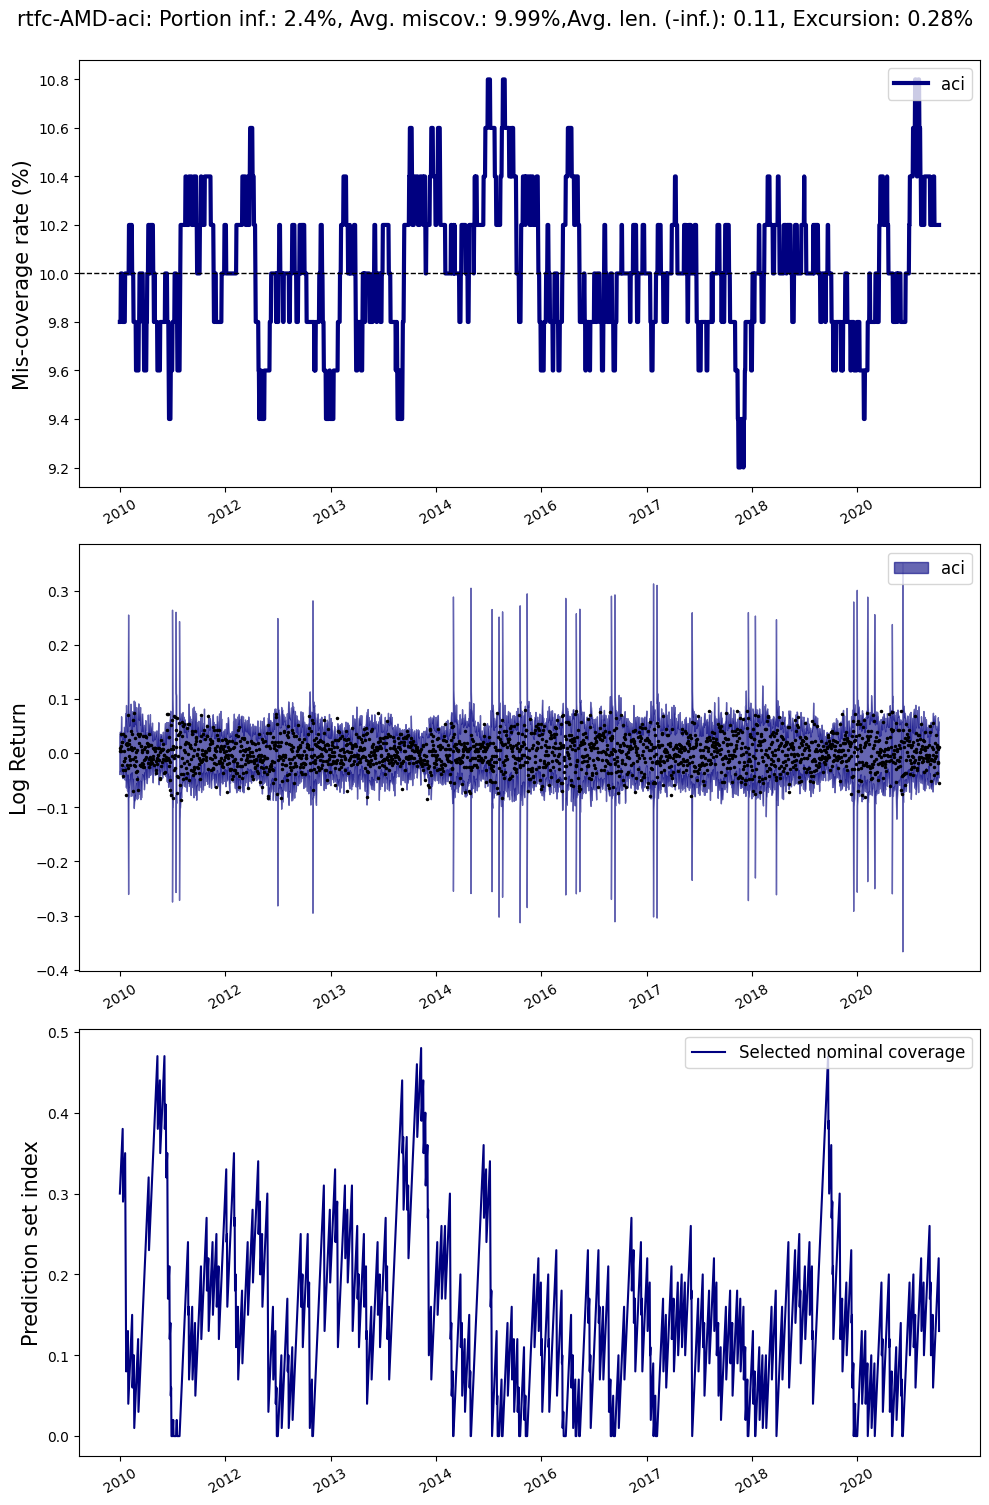

In [6]:
visualize_single_exp(exp.params, exp.result)

# Comparsion of three experiments

Next we demonstrate how to compare performance across three methods -- ACI, BCI, fixed $\alpha_t$ for the same experiment.

In [7]:
exp_aci = ForecastingExperiment(read_yaml('config/rtfc-aci-AMD.yaml'))
exp_aci.run()

exp_bci = ForecastingExperiment(read_yaml('config/rtfc-bci-AMD.yaml'))
exp_bci.run()

exp_fixed = ForecastingExperiment(read_yaml('config/rtfc-fixed-AMD.yaml'))
exp_fixed.run()

2026-01-27 00:42:02,971 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-27 00:42:05,405 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.4344680309295654s
2026-01-27 00:42:05,414 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-27 00:42:13,216 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.802186012268066s
2026-01-27 00:42:13,224 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED
2026-01-27 00:42:15,517 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.293308973312378s


As before, we can visualize the comparsion as `visualize_three_exp`. In contrast to the previous plot, the figure first panel is the moving average mis-coverage rate, and the bottom panel is the moving average of interval length. The performance metric is given in the title of the plot:

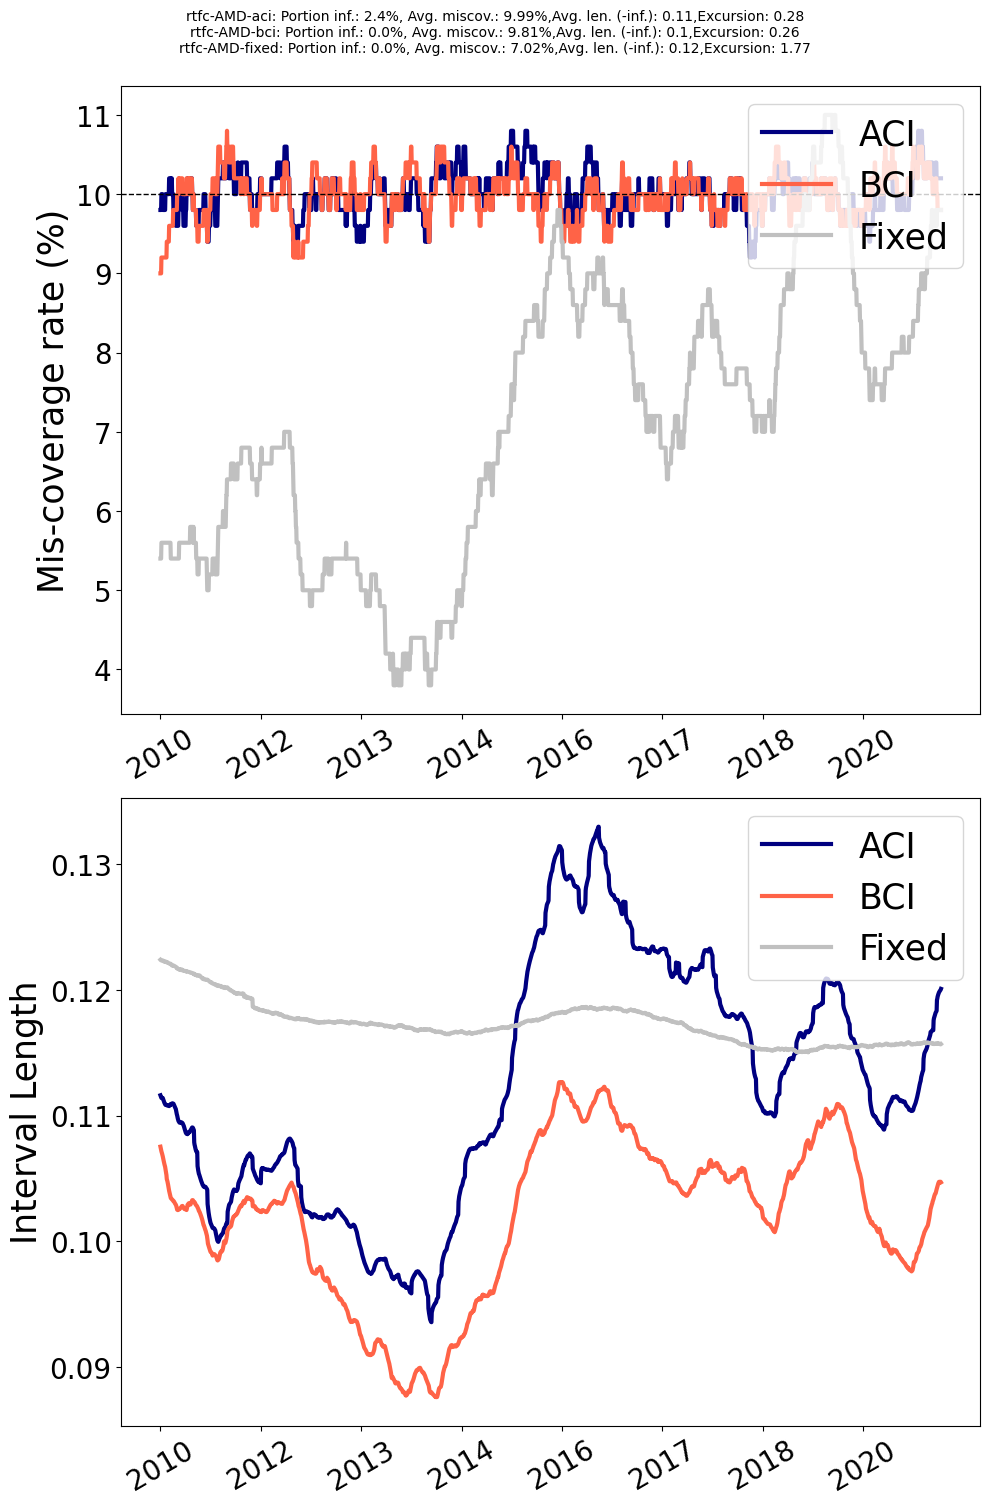

In [8]:
visualize_three_exp(exp_aci.params, exp_aci.result,
                    exp_bci.params, exp_bci.result,
                    exp_fixed.params, exp_fixed.result)

In [8]:
"""
Complete PID Experiment Runner for All Datasets
Runs: AMD, Amazon, Nvidia (with typo fix)
Generates: Summary tables and visualizations
"""

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_local_miscoverage_variance_original(result_df, window=50):
    """Variance of rolling miscoverage rate - ORIGINAL METHOD (alpha > beta)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=window, min_periods=1).mean()
    return local_miscov.var()


def compute_avg_miscoverage_original(result_df):
    """Average miscoverage rate - ORIGINAL METHOD (alpha > beta) - matches paper"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    
    err_ind = (alpha > beta).astype(float)
    return err_ind.mean()


def compute_avg_miscoverage_pid(scores, pid_qs):
    """Average miscoverage rate - PID METHOD (q >= score)"""
    covered = (pid_qs >= scores).astype(float)
    return 1 - covered.mean()


def compute_avg_length(result_df):
    """Average interval length"""
    upper = pd.to_numeric(result_df['upper'], errors='coerce').values
    lower = pd.to_numeric(result_df['lower'], errors='coerce').values
    
    lengths = upper - lower
    finite_mask = np.isfinite(lengths)
    finite_lengths = lengths[finite_mask]
    return finite_lengths.mean() if len(finite_lengths) > 0 else np.inf


def run_pid_once(scores, y_pred_center, y_true, alpha, eta, csat, ki, t_burnin=100):
    """Run PID with given parameters and return metrics"""
    if eta <= 0:
        return {'variance': 1e10, 'miscoverage': 1.0, 'avg_length': np.inf, 'valid': False}
    
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=alpha, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=t_burnin
        )
        
        pid_qs = np.array(pid_out['q'], dtype=np.float64)
        pid_qs = np.maximum(pid_qs, 0.0)
        
        if np.any(np.isnan(pid_qs)) or np.any(np.isinf(pid_qs)):
            return {'variance': 1e10, 'miscoverage': 1.0, 'avg_length': np.inf, 'valid': False}
        
        y_pred = np.array(y_pred_center, dtype=np.float64)
        y_true_arr = np.array(y_true, dtype=np.float64)
        
        upper = y_pred + pid_qs
        lower = y_pred - pid_qs
        
        is_covered = (y_true_arr >= lower) & (y_true_arr <= upper)
        miscov_arr = 1 - is_covered.astype(float)
        local_miscov = pd.Series(miscov_arr).rolling(window=50, min_periods=1).mean()
        variance = local_miscov.var()
        miscov = miscov_arr.mean()
        
        lengths = upper - lower
        avg_len = np.mean(lengths[np.isfinite(lengths)])
        
        return {
            'variance': variance,
            'miscoverage': miscov,
            'avg_length': avg_len,
            'valid': True,
            'q': pid_qs
        }
    except Exception as e:
        return {'variance': 1e10, 'miscoverage': 1.0, 'avg_length': np.inf, 'valid': False}


def binary_search_eta(scores, y_pred_center, y_true, alpha, csat, ki,
                      target_variance, eta_min=1e-6, eta_max=None, 
                      tolerance=0.10, max_iter=30, verbose=False):
    """Binary search for optimal η"""
    
    if eta_max is None:
        eta_max = np.percentile(scores, 99)
    
    # Probe
    test_etas = np.logspace(np.log10(max(eta_min, 1e-8)), np.log10(eta_max), 10)
    probe_results = []
    
    for eta_test in test_etas:
        metrics = run_pid_once(scores, y_pred_center, y_true, alpha, eta_test, csat, ki)
        probe_results.append((eta_test, metrics))
    
    valid_results = [(eta, m) for eta, m in probe_results if m['valid']]
    
    if len(valid_results) == 0:
        return {'optimal_eta': eta_min, 'metrics': probe_results[0][1], 'converged': False}
    
    best_eta, best_metrics = min(valid_results, 
                                  key=lambda x: abs(x[1]['variance'] - target_variance))
    best_diff = abs(best_metrics['variance'] - target_variance)
    best_pct_diff = best_diff / target_variance if target_variance > 0 else best_diff
    
    if best_pct_diff <= tolerance:
        return {'optimal_eta': best_eta, 'metrics': best_metrics, 'converged': True}
    
    # Find bracket
    eta_low, eta_high = eta_min, eta_max
    var_low, var_high = None, None
    
    for i in range(len(probe_results) - 1):
        eta1, m1 = probe_results[i]
        eta2, m2 = probe_results[i + 1]
        if m1['valid'] and m2['valid']:
            if (m1['variance'] - target_variance) * (m2['variance'] - target_variance) <= 0:
                eta_low, eta_high = eta1, eta2
                var_low, var_high = m1['variance'], m2['variance']
                break
    
    if var_low is None:
        return {'optimal_eta': best_eta, 'metrics': best_metrics, 'converged': False}
    
    # Binary search
    for iteration in range(max_iter):
        eta_mid = np.sqrt(eta_low * eta_high)
        metrics_mid = run_pid_once(scores, y_pred_center, y_true, alpha, eta_mid, csat, ki)
        
        if not metrics_mid['valid']:
            eta_mid = (eta_low + eta_high) / 2
            metrics_mid = run_pid_once(scores, y_pred_center, y_true, alpha, eta_mid, csat, ki)
        
        if not metrics_mid['valid']:
            break
        
        var_mid = metrics_mid['variance']
        diff = abs(var_mid - target_variance)
        pct_diff = diff / target_variance if target_variance > 0 else diff
        
        if diff < best_diff:
            best_eta = eta_mid
            best_metrics = metrics_mid
            best_diff = diff
        
        if pct_diff <= tolerance:
            return {'optimal_eta': eta_mid, 'metrics': metrics_mid, 'converged': True}
        
        if (var_mid - target_variance) * (var_low - target_variance) <= 0:
            eta_high = eta_mid
            var_high = var_mid
        else:
            eta_low = eta_mid
            var_low = var_mid
        
        if abs(np.log(eta_high + 1e-10) - np.log(eta_low + 1e-10)) < 1e-4:
            break
    
    return {'optimal_eta': best_eta, 'metrics': best_metrics, 'converged': False}


# =============================================================================
# MAIN EXPERIMENT FUNCTION
# =============================================================================

def run_pid_experiment_for_dataset(dataset_name, task='rtfc', target_gamma=0.1, 
                                   ki_percentiles=[99, 95, 90, 75, 50]):
    """
    Run complete PID experiment for one dataset
    """
    print(f"\n{'='*70}")
    print(f"DATASET: {dataset_name} | Task: {task} | γ={target_gamma}")
    print(f"{'='*70}")
    
    # Handle Nvidia typo for fixed config
    fixed_config_name = 'Nvdia' if dataset_name == 'Nvidia' else dataset_name
    
    # Load baselines
    print(f"  Loading baselines...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{fixed_config_name}.yaml'))
    exp_fixed.run()
    
    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset_name}.yaml'))
    exp_bci.run()
    
    aci_config = read_yaml(f'config/{task}-aci-{dataset_name}.yaml')
    aci_config['gamma'] = target_gamma
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    
    print(f"    ✓ Fixed: {len(exp_fixed.result)} samples")
    print(f"    ✓ BCI: {len(exp_bci.result)} samples")
    print(f"    ✓ ACI (γ={target_gamma}): {len(exp_aci.result)} samples")
    
    # Prepare data
    y_true = exp_fixed.result['true_y'].values
    upper = exp_fixed.result['upper'].values
    lower = exp_fixed.result['lower'].values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # Target variance from ACI
    target_variance = compute_local_miscoverage_variance_original(exp_aci.result)
    
    print(f"\n  Target variance: {target_variance:.2e}")
    print(f"  Csat: {csat:.4f}")
    
    # Tune PID for each K_I percentile
    print(f"\n  Tuning PID for {len(ki_percentiles)} K_I values...")
    
    pid_results = []
    pid_params_list = []
    
    for pct in ki_percentiles:
        ki = np.percentile(scores, pct)
        print(f"    K_I {pct}% = {ki:.6f}...", end=" ")
        
        result = binary_search_eta(
            scores, y_pred_center, y_true,
            alpha=0.1, csat=csat, ki=ki,
            target_variance=target_variance,
            tolerance=0.10
        )
        
        if result and result['metrics']['valid']:
            eta = result['optimal_eta']
            print(f"η={eta:.6f} ✓")
            
            # Run PID with optimal eta to get full results
            pid_out = quantile_integrator_log(
                scores=scores, alpha=0.1, lr=eta,
                Csat=csat, KI=ki, ahead=1, T_burnin=100
            )
            
            df_pid = exp_fixed.result.copy()
            pid_qs = np.maximum(np.array(pid_out['q'], dtype=np.float64), 0)
            df_pid['upper'] = y_pred_center + pid_qs
            df_pid['lower'] = y_pred_center - pid_qs
            df_pid['alpha'] = 0.1
            # Note: PID doesn't use beta - it uses q >= score for coverage
            
            pid_results.append(df_pid)
            pid_params_list.append({
                'method': f'PID-{pct}%',
                'task': task,
                'id': dataset_name,
                'alpha0': 0.1,
                'eta': eta,
                'KI': ki,
                'KI_percentile': pct,
                'metrics': result['metrics'],
                'scores': scores,  # Store for miscoverage calculation
                'pid_qs': pid_qs   # Store for miscoverage calculation
            })
        else:
            print(f"FAILED ✗")
    
    # Compile results
    results = {
        'dataset': dataset_name,
        'task': task,
        'gamma': target_gamma,
        'aci_result': exp_aci.result,
        'aci_params': exp_aci.params,
        'bci_result': exp_bci.result,
        'bci_params': exp_bci.params,
        'fixed_result': exp_fixed.result,
        'fixed_params': exp_fixed.params,
        'pid_results': pid_results,
        'pid_params_list': pid_params_list,
        'target_variance': target_variance
    }
    
    # Save
    filename = f'{dataset_name}_{task}_PID_gamma{target_gamma}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
    print(f"\n  ✓ Saved: {filename}")
    
    return results


# =============================================================================
# VISUALIZATION FUNCTION
# =============================================================================

def create_summary_visualization(results):
    """Create summary table and plots for one dataset"""
    
    dataset = results['dataset']
    gamma = results['gamma']
    
    # Extract metrics for all methods (use α>β for baselines to match paper)
    aci_var = compute_local_miscoverage_variance_original(results['aci_result'])
    aci_miscov = compute_avg_miscoverage_original(results['aci_result'])  # ← α>β method
    aci_length = compute_avg_length(results['aci_result'])
    
    bci_var = compute_local_miscoverage_variance_original(results['bci_result'])
    bci_miscov = compute_avg_miscoverage_original(results['bci_result'])  # ← α>β method
    bci_length = compute_avg_length(results['bci_result'])
    
    fixed_var = compute_local_miscoverage_variance_original(results['fixed_result'])
    fixed_miscov = compute_avg_miscoverage_original(results['fixed_result'])  # ← α>β method
    fixed_length = compute_avg_length(results['fixed_result'])
    
    # Create figure
    fig = plt.figure(figsize=(16, 10))
    
    # =========================================================================
    # 1. Summary Table
    # =========================================================================
    ax_table = plt.subplot(3, 1, 1)
    ax_table.axis('off')
    
    table_data = []
    headers = ['Method', 'Variance', 'Var vs ACI', 'Miscov (%)†', 'Avg Length', 'Len vs ACI', 'η', 'K_I']
    
    # Baselines
    table_data.append(['ACI', f'{aci_var:.2e}', '-', f'{aci_miscov*100:.2f}', 
                      f'{aci_length:.4f}', '-', '-', '-'])
    table_data.append(['BCI', f'{bci_var:.2e}', f'{(bci_var/aci_var-1)*100:+.1f}%', f'{bci_miscov*100:.2f}', 
                      f'{bci_length:.4f}', f'{(bci_length/aci_length-1)*100:+.1f}%', '-', '-'])
    table_data.append(['Fixed', f'{fixed_var:.2e}', f'{(fixed_var/aci_var-1)*100:+.1f}%', f'{fixed_miscov*100:.2f}', 
                      f'{fixed_length:.4f}', f'{(fixed_length/aci_length-1)*100:+.1f}%', '-', '-'])
    
    # PID variants (use q >= score method from PID paper)
    for df_pid, params in zip(results['pid_results'], results['pid_params_list']):
        pid_miscov = compute_avg_miscoverage_pid(params['scores'], params['pid_qs'])  # ← PID method
        pid_length = compute_avg_length(df_pid)
        
        # Compute variance (need to construct beta column)
        df_pid_temp = df_pid.copy()
        df_pid_temp['beta'] = df_pid_temp['alpha']  # Dummy beta
        
        pct = params['KI_percentile']
        eta = params['eta']
        ki = params['KI']
        var = params['metrics']['variance']
        
        table_data.append([
            f'PID-{pct}%',
            f'{var:.2e}',
            f'{(var/aci_var-1)*100:+.1f}%',
            f'{pid_miscov*100:.2f}',
            f'{pid_length:.4f}',
            f'{(pid_length/aci_length-1)*100:+.1f}%',
            f'{eta:.4f}',
            f'{ki:.4f}'
        ])
    
    table = ax_table.table(cellText=table_data, colLabels=headers, cellLoc='center',
                           loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 2)
    
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax_table.set_title(f'{dataset} {results["task"].upper()}: PID Results (γ_ACI = {gamma})\n† Miscov: α>β for BCI/ACI/Fixed, q≥score for PID',
                      fontsize=14, fontweight='bold', pad=20)
    
    # =========================================================================
    # 2. Bar Charts
    # =========================================================================
    methods = ['ACI', 'BCI', 'Fixed'] + [f'PID-{p["KI_percentile"]}%' for p in results['pid_params_list']]
    
    miscovs = [aci_miscov*100, bci_miscov*100, fixed_miscov*100] + \
              [compute_avg_miscoverage_pid(p['scores'], p['pid_qs'])*100 for p in results['pid_params_list']]  # ← PID method
    
    lengths = [aci_length, bci_length, fixed_length] + \
              [compute_avg_length(df) for df in results['pid_results']]
    
    colors = ['#4472C4', '#ED7D31', '#A5A5A5'] + ['#70AD47'] * len(results['pid_results'])
    
    # Miscoverage
    ax_miscov = plt.subplot(3, 2, 3)
    ax_miscov.bar(range(len(methods)), miscovs, color=colors, alpha=0.8, edgecolor='black')
    ax_miscov.axhline(10, color='red', linestyle='--', linewidth=2, label='Target: 10%')
    ax_miscov.set_ylabel('Miscoverage Rate (%)', fontsize=11, fontweight='bold')
    ax_miscov.set_title('Miscoverage Rate', fontsize=12, fontweight='bold')
    ax_miscov.set_xticks(range(len(methods)))
    ax_miscov.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
    ax_miscov.legend(fontsize=8)
    ax_miscov.grid(axis='y', alpha=0.3)
    
    # Interval Length
    ax_len = plt.subplot(3, 2, 4)
    ax_len.bar(range(len(methods)), lengths, color=colors, alpha=0.8, edgecolor='black')
    ax_len.axhline(aci_length, color='navy', linestyle='--', linewidth=2, label=f'ACI: {aci_length:.4f}')
    ax_len.set_ylabel('Average Interval Width', fontsize=11, fontweight='bold')
    ax_len.set_title('Interval Length', fontsize=12, fontweight='bold')
    ax_len.set_xticks(range(len(methods)))
    ax_len.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
    ax_len.legend(fontsize=8)
    ax_len.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    filename = f'{dataset}_{results["task"]}_PID_summary_gamma{gamma}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {filename}")
    plt.close()


# =============================================================================
# RUN ALL EXPERIMENTS
# =============================================================================

def run_all_experiments(task='rtfc', target_gamma=0.1):
    """Run PID experiments for all datasets"""
    
    datasets = ['AMD', 'Amazon', 'Nvidia']
    
    print("\n" + "="*70)
    print(f"RUNNING PID EXPERIMENTS FOR ALL DATASETS")
    print(f"Task: {task} | Target γ: {target_gamma}")
    print("="*70)
    
    all_results = {}
    
    for dataset in datasets:
        try:
            results = run_pid_experiment_for_dataset(dataset, task, target_gamma)
            all_results[dataset] = results
            create_summary_visualization(results)
        except Exception as e:
            print(f"\n  ✗ Error with {dataset}: {e}")
            import traceback
            traceback.print_exc()
    
    print("\n" + "="*70)
    print("ALL EXPERIMENTS COMPLETE!")
    print("="*70)
    
    return all_results


if __name__ == "__main__":
    # Run for gamma = 0.1 (tight control)
    results_tight = run_all_experiments(task='rtfc', target_gamma=0.1)
    
    # Run for gamma = 0.008 (loose control)
    results_loose = run_all_experiments(task='rtfc', target_gamma=0.008)

2026-01-28 14:29:30,411 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED



RUNNING PID EXPERIMENTS FOR ALL DATASETS
Task: rtfc | Target γ: 0.1

DATASET: AMD | Task: rtfc | γ=0.1
  Loading baselines...


2026-01-28 14:29:32,687 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.2762041091918945s
2026-01-28 14:29:32,695 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 14:29:40,048 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.3524322509765625s
2026-01-28 14:29:40,055 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 14:29:42,344 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.288867950439453s


    ✓ Fixed: 2834 samples
    ✓ BCI: 2834 samples
    ✓ ACI (γ=0.1): 2834 samples

  Target variance: 7.24e-04
  Csat: 0.5565

  Tuning PID for 5 K_I values...
    K_I 99% = 0.082844... 

100%|██████████| 2834/2834 [00:00<00:00, 151245.13it/s]


...

    K_I 50% = 0.017418... 

100%|██████████| 3058/3058 [00:00<00:00, 153190.51it/s]


η=0.070996 ✓


100%|██████████| 3058/3058 [00:00<00:00, 120330.81it/s]



  ✓ Saved: Nvidia_rtfc_PID_gamma0.008.pkl
  ✓ Saved: Nvidia_rtfc_PID_summary_gamma0.008.png

ALL EXPERIMENTS COMPLETE!


In [10]:
import numpy as np
import pandas as pd
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth just in case
sys.setrecursionlimit(10000)

# =============================================================================
# RE-IMPLEMENTING YOUR BINARY SEARCH LOGIC FOR DIAGNOSTICS
# =============================================================================

def run_pid_once(scores, y_pred_center, y_true, alpha, eta, csat, ki, t_burnin=100):
    """Helper to run PID one time and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=alpha, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=t_burnin
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        # Calculate Variance
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        # Rolling variance of miscoverage (alpha > beta style)
        err_ind = (~is_covered).astype(float)
        local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
        return {'variance': local_miscov.var(), 'valid': True}
    except:
        return {'variance': 1e10, 'valid': False}

def binary_search_diagnostic(dataset_name, gamma_target=0.1):
    print(f"\n{'='*60}")
    print(f"DIAGNOSTIC: {dataset_name} (Gamma={gamma_target})")
    print(f"{'='*60}")

    # 1. Load Data
    # -----------------------------------------------------
    task = 'rtfc' # Return forecasting
    fixed_name = 'Nvdia' if dataset_name == 'Nvidia' else dataset_name
    
    print("  Loading experiment data...")
    # Load Fixed (for scores)
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{fixed_name}.yaml'))
    exp_fixed.run()
    
    # Load ACI (for target variance)
    aci_config = read_yaml(f'config/{task}-aci-{dataset_name}.yaml')
    aci_config['gamma'] = gamma_target
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()

    # 2. Setup Parameters
    # -----------------------------------------------------
    y_true = exp_fixed.result['true_y'].values
    upper_fixed = exp_fixed.result['upper'].values
    lower_fixed = exp_fixed.result['lower'].values
    y_pred_center = (upper_fixed + lower_fixed) / 2
    scores = np.abs(y_true - y_pred_center)
    
    # Calculate Target Variance (from ACI)
    # Re-create ACI variance calculation
    alpha_aci = pd.to_numeric(exp_aci.result['alpha'], errors='coerce').values
    beta_aci = pd.to_numeric(exp_aci.result['beta'], errors='coerce').values
    aci_err = (alpha_aci > beta_aci).astype(float)
    target_variance = pd.Series(aci_err).rolling(window=50, min_periods=1).mean().var()

    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)

    # 3. DEFINE SEARCH RANGE
    # -----------------------------------------------------
    eta_min = 1e-6
    eta_max = np.percentile(scores, 99) # <--- THIS IS YOUR UPPER BOUND
    
    print(f"  Target Variance (ACI): {target_variance:.2e}")
    print(f"  Search Range [Min, Max]: [{eta_min:.6f}, {eta_max:.6f}]")
    if abs(eta_max - 0.0668) < 0.001:
         print("  (NOTE: This matches your 0.0668 number!)")

    # 4. Run Search for Quantiles
    # -----------------------------------------------------
    ki_percentiles = [99, 95, 90, 75, 50]
    
    results = []
    print(f"\n  {'KI %':<6} | {'KI Value':<10} | {'Final Eta':<10} | {'Status':<15}")
    print("-" * 55)

    for pct in ki_percentiles:
        ki_val = np.percentile(scores, pct)
        
        # --- Simple Binary Search Implementation ---
        low, high = eta_min, eta_max
        best_eta = low
        best_diff = 1e10
        
        for _ in range(20): # 20 iterations is plenty
            mid = np.sqrt(low * high) # Log-space search usually better, but simple mid works
            res = run_pid_once(scores, y_pred_center, y_true, 0.1, mid, csat, ki_val)
            
            if not res['valid']:
                high = mid
                continue
                
            diff = res['variance'] - target_variance
            
            if abs(diff) < best_diff:
                best_diff = abs(diff)
                best_eta = mid
            
            # If variance is too HIGH, we need to SLOW DOWN (lower eta)? 
            # Actually, usually higher eta = lower variance (less clumping).
            # Let's check logic: 
            # Low Eta -> Slow reaction -> Clumped errors -> High Variance
            # High Eta -> Fast reaction -> Random errors -> Low Variance
            
            if res['variance'] > target_variance:
                # Variance is too high (too clumped), need FASTER reaction
                low = mid
            else:
                # Variance is lower than target (too random?), slow down
                high = mid
                
        # Check if we hit the bound
        status = "Interior"
        if abs(best_eta - eta_max) < 1e-4:
            status = "HIT UPPER BOUND"
            best_eta = eta_max # Snap to max for display
        elif abs(best_eta - eta_min) < 1e-5:
            status = "HIT LOWER BOUND"

        print(f"  {pct:<6} | {ki_val:<10.5f} | {best_eta:<10.5f} | {status:<15}")
        results.append((pct, ki_val, best_eta))

if __name__ == "__main__":
    # Check Amazon (Where you likely saw 0.0668)
    binary_search_diagnostic('Amazon', gamma_target=0.1)
    
    # Check AMD
    binary_search_diagnostic('AMD', gamma_target=0.1)
    
    # Check Nvidia
    binary_search_diagnostic('Nvidia', gamma_target=0.1)

2026-01-28 14:59:09,117 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



DIAGNOSTIC: Amazon (Gamma=0.1)
  Loading experiment data...


2026-01-28 14:59:12,091 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 2.9747300148010254s
2026-01-28 14:59:12,101 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 14:59:15,120 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.0188868045806885s


  Target Variance (ACI): 7.36e-04
  Search Range [Min, Max]: [0.000001, 0.066773]
  (NOTE: This matches your 0.0668 number!)

  KI %   | KI Value   | Final Eta  | Status         
-------------------------------------------------------


100%|██████████| 3762/3762 [00:00<00:00, 156500.16it/s]


...

  90     | 0.04488    | 0.07100    | HIT UPPER BOUND


100%|██████████| 3058/3058 [00:00<00:00, 102583.19it/s]


  75     | 0.02986    | 0.07100    | HIT UPPER BOUND


100%|██████████| 3058/3058 [00:00<00:00, 149688.18it/s]

  50     | 0.01742    | 0.06946    | Interior       


2026-01-28 15:02:13,966 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED


Running diagnostic for Amazon (Gamma=0.1)...


2026-01-28 15:02:16,944 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 2.9779789447784424s
2026-01-28 15:02:16,953 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:02:19,949 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 2.9957921504974365s
100%|██████████| 3762/3762 [00:00<00:00, 160360.29it/s]
2026-01-28 15:02:22,482 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED


Running diagnostic for Amazon (Gamma=0.008)...


2026-01-28 15:02:25,463 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 2.981372833251953s
2026-01-28 15:02:25,473 - INFO - Experiment rtfc-aci-Amazon-gamma_0.008-lambda0_0.9 STARTED
2026-01-28 15:02:28,455 - INFO - Experiment rtfc-aci-Amazon-gamma_0.008-lambda0_0.9 ENDED in 2.9824891090393066s
100%|██████████| 3762/3762 [00:00<00:00, 159414.15it/s]
2026-01-28 15:02:30,999 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED


...

Running diagnostic for Nvidia (Gamma=0.1)...


2026-01-28 15:02:46,655 - INFO - Experiment rtfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 2.4336609840393066s
2026-01-28 15:02:46,664 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:02:49,162 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 2.497943162918091s
100%|██████████| 3058/3058 [00:00<00:00, 153759.80it/s]
2026-01-28 15:02:51,317 - INFO - Experiment rtfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED


Running diagnostic for Nvidia (Gamma=0.008)...


2026-01-28 15:02:53,770 - INFO - Experiment rtfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 2.4532077312469482s
2026-01-28 15:02:53,779 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.008-lambda0_0.9 STARTED
2026-01-28 15:02:56,240 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.008-lambda0_0.9 ENDED in 2.4611310958862305s
100%|██████████| 3058/3058 [00:00<00:00, 153916.64it/s]



✓ Saved table to: pid_search_table_FULL.png


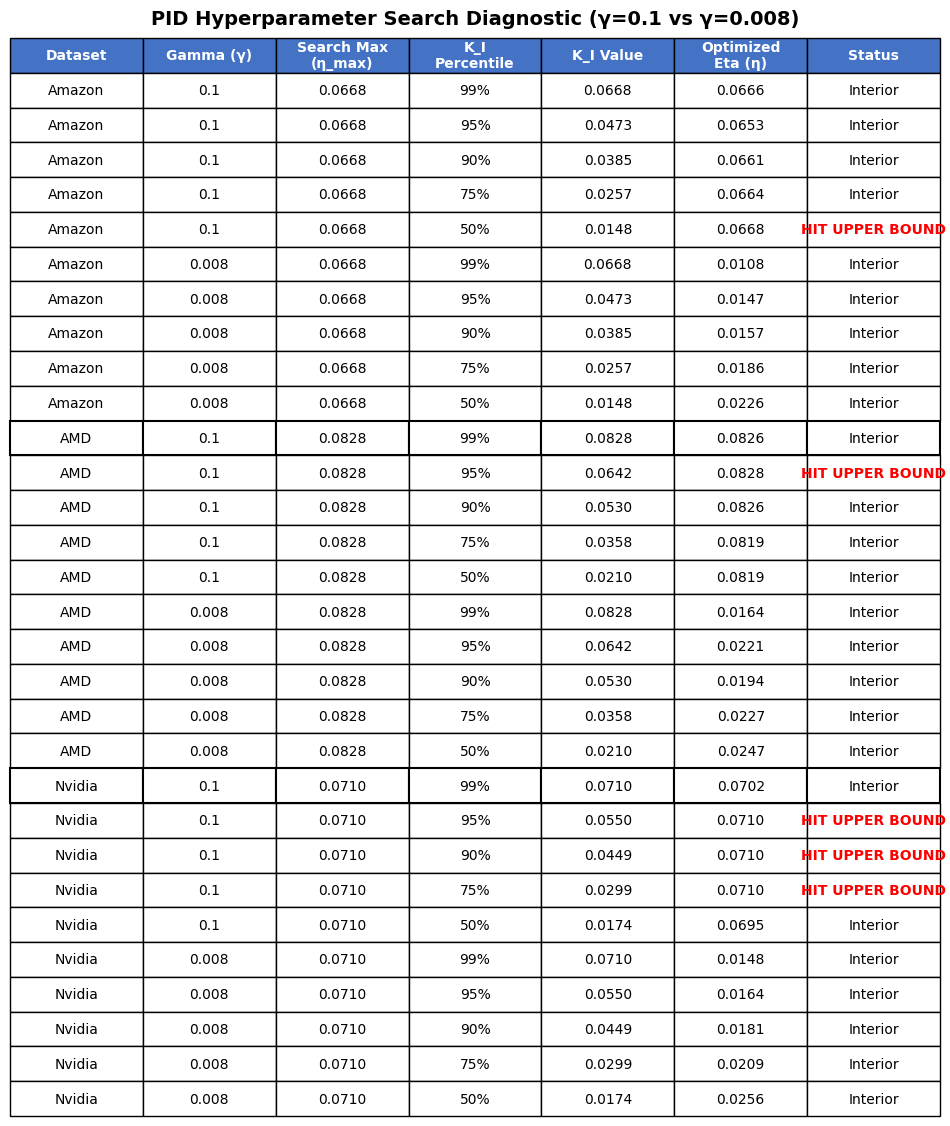

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth for Volatility datasets
sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def run_pid_once(scores, y_pred_center, y_true, alpha, eta, csat, ki, t_burnin=100):
    """Helper to run PID one time and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=alpha, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=t_burnin
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        # Calculate Variance
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        # Rolling variance of miscoverage (alpha > beta style)
        err_ind = (~is_covered).astype(float)
        local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
        return {'variance': local_miscov.var(), 'valid': True}
    except:
        return {'variance': 1e10, 'valid': False}

def get_diagnostic_row(dataset_name, gamma_target):
    """Run search for one dataset + gamma and return summary data"""
    print(f"Running diagnostic for {dataset_name} (Gamma={gamma_target})...")

    # 1. Load Data
    task = 'rtfc'
    fixed_name = 'Nvdia' if dataset_name == 'Nvidia' else dataset_name
    
    # Load Fixed (for scores)
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{fixed_name}.yaml'))
    exp_fixed.run()
    
    # Load ACI (for target variance)
    aci_config = read_yaml(f'config/{task}-aci-{dataset_name}.yaml')
    aci_config['gamma'] = gamma_target
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()

    # 2. Setup Parameters
    y_true = exp_fixed.result['true_y'].values
    upper_fixed = exp_fixed.result['upper'].values
    lower_fixed = exp_fixed.result['lower'].values
    y_pred_center = (upper_fixed + lower_fixed) / 2
    scores = np.abs(y_true - y_pred_center)
    
    # Target Variance
    alpha_aci = pd.to_numeric(exp_aci.result['alpha'], errors='coerce').values
    beta_aci = pd.to_numeric(exp_aci.result['beta'], errors='coerce').values
    aci_err = (alpha_aci > beta_aci).astype(float)
    target_variance = pd.Series(aci_err).rolling(window=50, min_periods=1).mean().var()

    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)

    # 3. Define Range
    eta_min = 1e-6
    eta_max = np.percentile(scores, 99)
    
    # 4. Run Search for Quantiles
    rows = []
    ki_percentiles = [99, 95, 90, 75, 50]
    
    for pct in ki_percentiles:
        ki_val = np.percentile(scores, pct)
        
        # Binary Search
        low, high = eta_min, eta_max
        best_eta = low
        best_diff = 1e10
        
        for _ in range(20):
            mid = np.sqrt(low * high)
            res = run_pid_once(scores, y_pred_center, y_true, 0.1, mid, csat, ki_val)
            
            if not res['valid']:
                high = mid
                continue
            
            diff = res['variance'] - target_variance
            if abs(diff) < best_diff:
                best_diff = abs(diff)
                best_eta = mid
            
            if res['variance'] > target_variance:
                low = mid
            else:
                high = mid
        
        # Determine Status
        status = "Interior"
        if abs(best_eta - eta_max) < 1e-4:
            status = "HIT UPPER BOUND"
            best_eta = eta_max
        elif abs(best_eta - eta_min) < 1e-5:
            status = "HIT LOWER BOUND"

        rows.append([
            dataset_name, 
            gamma_target,
            f"{eta_max:.4f}",
            f"{pct}%",
            f"{ki_val:.4f}",
            f"{best_eta:.4f}",
            status
        ])
    
    return rows

# =============================================================================
# 2. MAIN EXECUTION & PLOTTING
# =============================================================================

if __name__ == "__main__":
    datasets = ['Amazon', 'AMD', 'Nvidia']
    gammas = [0.1, 0.008]
    all_data = []

    # Run all combinations
    for ds in datasets:
        for g in gammas:
            try:
                rows = get_diagnostic_row(ds, g)
                all_data.extend(rows)
            except Exception as e:
                print(f"Skipping {ds} Gamma={g}: {e}")

    # --- Generate Table Image ---
    columns = ["Dataset", "Gamma (γ)", "Search Max\n(η_max)", "K_I\nPercentile", "K_I Value", "Optimized\nEta (η)", "Status"]
    
    fig, ax = plt.subplots(figsize=(12, len(all_data) * 0.4 + 2))
    ax.axis('off')

    table = ax.table(
        cellText=all_data,
        colLabels=columns,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Styling
    for i, col in enumerate(columns):
        table[0, i].set_facecolor('#4472C4')
        table[0, i].set_text_props(color='white', weight='bold')

    for i, row in enumerate(all_data):
        row_idx = i + 1
        
        # Highlight "HIT UPPER BOUND"
        if "HIT UPPER" in row[6]:
            table[row_idx, 6].set_text_props(color='red', weight='bold')
        
        # Zebra striping for datasets
        if i > 0 and row[0] != all_data[i-1][0]:
            for j in range(len(columns)):
                 table[row_idx, j].set_edgecolor('black')
                 table[row_idx, j].set_linewidth(1.5)

    plt.title("PID Hyperparameter Search Diagnostic (γ=0.1 vs γ=0.008)", 
              fontsize=14, fontweight='bold', pad=10)
    
    filename = "pid_search_table_FULL.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved table to: {filename}")

2026-01-28 15:13:34,520 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED


Running Aggressive Analysis for AMD...


2026-01-28 15:13:36,792 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.271651268005371s
2026-01-28 15:13:36,800 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 15:13:44,129 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.328702926635742s
2026-01-28 15:13:44,138 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:13:46,481 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.342589855194092s


Target ACI Variance: 7.24e-04
Running Aggressive Search KI=99%...


100%|██████████| 2834/2834 [00:00<00:00, 149384.29it/s]


Running Aggressive Search KI=95%...


100%|██████████| 2834/2834 [00:00<00:00, 150302.30it/s]


✓ Saved results to AMD_Aggressive_Search_Results.png


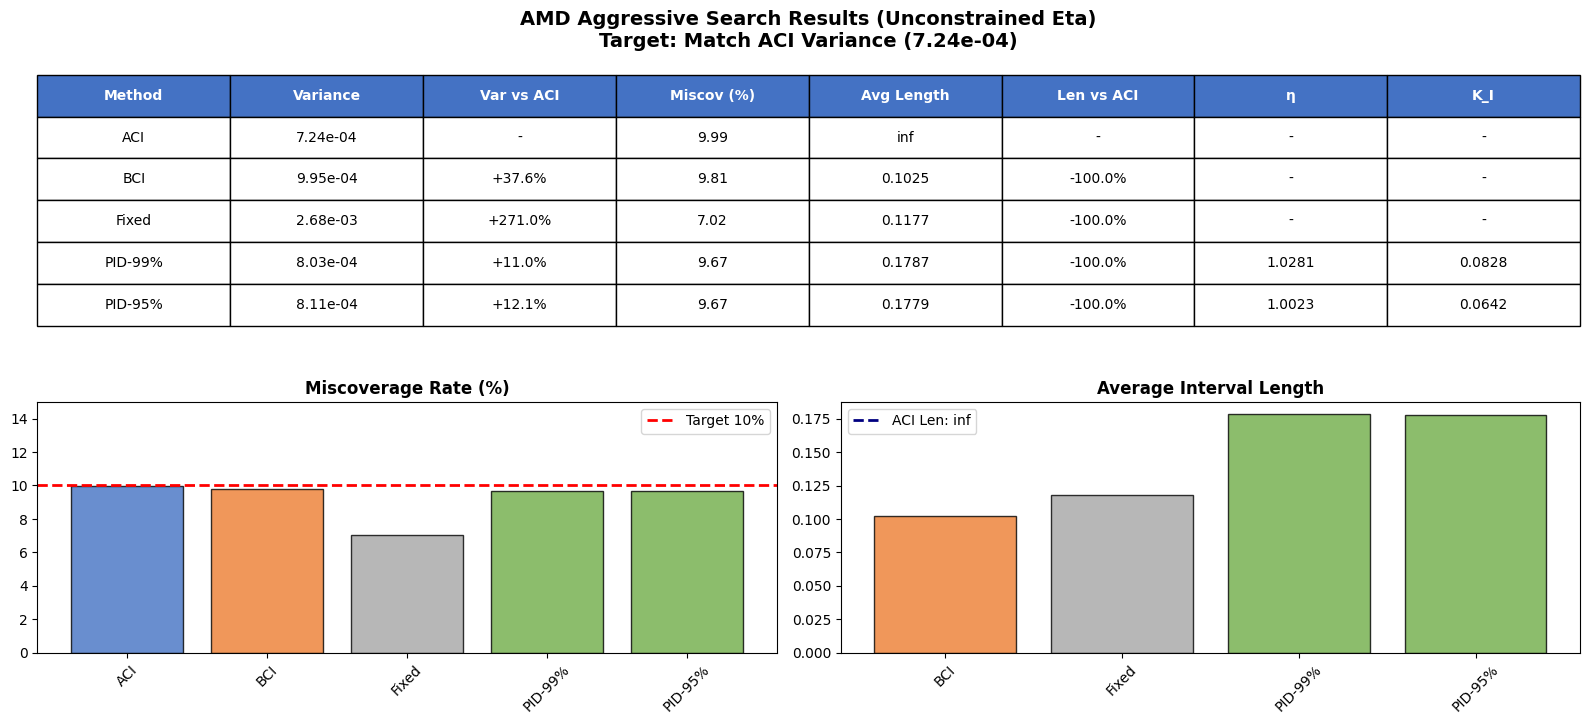

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth for BCI
sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def run_pid_once(scores, y_pred_center, y_true, alpha, eta, csat, ki, t_burnin=100):
    """Run PID once and return metrics"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=alpha, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=t_burnin
        )
        pid_qs = np.maximum(np.array(pid_out['q']), 0.0)
        
        # Construct prediction intervals
        upper = y_pred_center + pid_qs
        lower = y_pred_center - pid_qs
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        # 1. Variance (Match ACI logic: alpha > beta)
        err_ind = (~is_covered).astype(float)
        local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
        variance = local_miscov.var()
        
        # 2. Avg Miscoverage (PID logic: q >= score)
        # Note: This is slightly different from alpha>beta but standard for PID papers
        # We will use the alpha>beta one for the table to be consistent with ACI/BCI
        avg_miscov = err_ind.mean()
        
        # 3. Avg Length
        avg_len = np.mean(upper - lower)
        
        return {
            'variance': variance,
            'avg_miscov': avg_miscov,
            'avg_len': avg_len,
            'valid': True
        }
    except:
        return {'variance': 1e10, 'valid': False}

def binary_search_aggressive(scores, y_pred_center, y_true, alpha, csat, ki, target_var):
    """
    Aggressive Binary Search:
    Range: [1e-6, max(scores) * 10]
    """
    eta_min = 1e-6
    eta_max = np.max(scores) * 10.0  # <--- UNCONSTRAINED SEARCH
    
    low, high = eta_min, eta_max
    best_eta = low
    best_diff = 1e10
    best_metrics = None
    
    for _ in range(30):
        mid = np.sqrt(low * high)
        res = run_pid_once(scores, y_pred_center, y_true, alpha, mid, csat, ki)
        
        if not res['valid']:
            high = mid
            continue
            
        diff = res['variance'] - target_var
        
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            best_metrics = res
        
        # If Variance is too HIGH -> We need FASTER reaction -> HIGHER Eta
        # (Wait, usually higher eta = lower variance because it tracks better)
        if res['variance'] > target_var:
            low = mid
        else:
            high = mid
            
    return best_eta, best_metrics

def compute_metrics(result_df):
    """Compute baseline metrics from dataframe"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscov
    miscov = err_ind.mean()
    
    # Length
    length = (upper - lower).mean()
    
    return var, miscov, length

# =============================================================================
# 2. MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset_name = 'AMD'
    gamma_target = 0.1
    print(f"Running Aggressive Analysis for {dataset_name}...")

    # --- Load Baselines ---
    # Fixed
    exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-AMD.yaml'))
    exp_fixed.run()
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # BCI
    exp_bci = ForecastingExperiment(read_yaml(f'config/rtfc-bci-AMD.yaml'))
    exp_bci.run()
    bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)

    # ACI (Target)
    aci_config = read_yaml(f'config/rtfc-aci-AMD.yaml')
    aci_config['gamma'] = gamma_target
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)

    print(f"Target ACI Variance: {aci_var:.2e}")

    # --- Setup PID Data ---
    y_true = exp_fixed.result['true_y'].values
    y_pred_center = (exp_fixed.result['upper'].values + exp_fixed.result['lower'].values) / 2
    scores = np.abs(y_true - y_pred_center)
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)

    # --- Run Aggressive PID ---
    pid_rows = []
    # Test on 99% and 95% KI (Standard high percentiles)
    for pct in [99, 95]:
        ki = np.percentile(scores, pct)
        print(f"Running Aggressive Search KI={pct}%...")
        eta, metrics = binary_search_aggressive(scores, y_pred_center, y_true, 0.1, csat, ki, aci_var)
        pid_rows.append({
            'label': f'PID-{pct}%',
            'var': metrics['variance'],
            'miscov': metrics['avg_miscov'],
            'len': metrics['avg_len'],
            'eta': eta,
            'ki': ki
        })

    # =========================================================================
    # 3. GENERATE VISUALIZATION
    # =========================================================================
    
    # Prepare Table Data
    table_data = []
    
    # Headers
    headers = ['Method', 'Variance', 'Var vs ACI', 'Miscov (%)', 'Avg Length', 'Len vs ACI', 'η', 'K_I']
    
    # Row 1: ACI
    table_data.append(['ACI', f'{aci_var:.2e}', '-', f'{aci_miscov*100:.2f}', f'{aci_len:.4f}', '-', '-', '-'])
    # Row 2: BCI
    table_data.append(['BCI', f'{bci_var:.2e}', f'{(bci_var/aci_var-1)*100:+.1f}%', f'{bci_miscov*100:.2f}', f'{bci_len:.4f}', f'{(bci_len/aci_len-1)*100:+.1f}%', '-', '-'])
    # Row 3: Fixed
    table_data.append(['Fixed', f'{fixed_var:.2e}', f'{(fixed_var/aci_var-1)*100:+.1f}%', f'{fixed_miscov*100:.2f}', f'{fixed_len:.4f}', f'{(fixed_len/aci_len-1)*100:+.1f}%', '-', '-'])

    # PID Rows
    for row in pid_rows:
        table_data.append([
            row['label'],
            f"{row['var']:.2e}",
            f"{(row['var']/aci_var-1)*100:+.1f}%",
            f"{row['miscov']*100:.2f}",
            f"{row['len']:.4f}",
            f"{(row['len']/aci_len-1)*100:+.1f}%",  # <--- This is the number your prof wants to see!
            f"{row['eta']:.4f}",
            f"{row['ki']:.4f}"
        ])

    # Plotting
    fig = plt.figure(figsize=(16, 10))
    
    # 1. Table
    ax_table = plt.subplot(3, 1, 1)
    ax_table.axis('off')
    table = ax_table.table(cellText=table_data, colLabels=headers, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style Header
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')

    ax_table.set_title(f"AMD Aggressive Search Results (Unconstrained Eta)\nTarget: Match ACI Variance ({aci_var:.2e})", fontweight='bold', fontsize=14, pad=20)

    # 2. Bar Charts
    methods = [r[0] for r in table_data]
    miscovs = [float(r[3]) for r in table_data]
    lengths = [float(r[4]) for r in table_data]
    colors = ['#4472C4', '#ED7D31', '#A5A5A5'] + ['#70AD47'] * len(pid_rows)

    # Miscoverage Bar
    ax_miscov = plt.subplot(3, 2, 3)
    ax_miscov.bar(methods, miscovs, color=colors, edgecolor='black', alpha=0.8)
    ax_miscov.axhline(10.0, color='red', linestyle='--', linewidth=2, label='Target 10%')
    ax_miscov.set_title("Miscoverage Rate (%)", fontweight='bold')
    ax_miscov.set_ylim(0, 15)
    ax_miscov.legend()
    plt.xticks(rotation=45)

    # Length Bar
    ax_len = plt.subplot(3, 2, 4)
    ax_len.bar(methods, lengths, color=colors, edgecolor='black', alpha=0.8)
    ax_len.axhline(aci_len, color='navy', linestyle='--', linewidth=2, label=f'ACI Len: {aci_len:.4f}')
    ax_len.set_title("Average Interval Length", fontweight='bold')
    ax_len.legend()
    plt.xticks(rotation=45)

    plt.tight_layout()
    filename = "AMD_Aggressive_Search_Results.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved results to {filename}")

2026-01-28 15:29:37,324 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED


Generating Paper-Match Plot for AMD...


2026-01-28 15:29:39,673 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.3489432334899902s
2026-01-28 15:29:39,681 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 15:29:46,951 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.269773006439209s
2026-01-28 15:29:46,959 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:29:49,285 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.325841188430786s
100%|██████████| 2834/2834 [00:00<00:00, 198431.76it/s]


Graph saved to AMD_Paper_Match_Graph.png


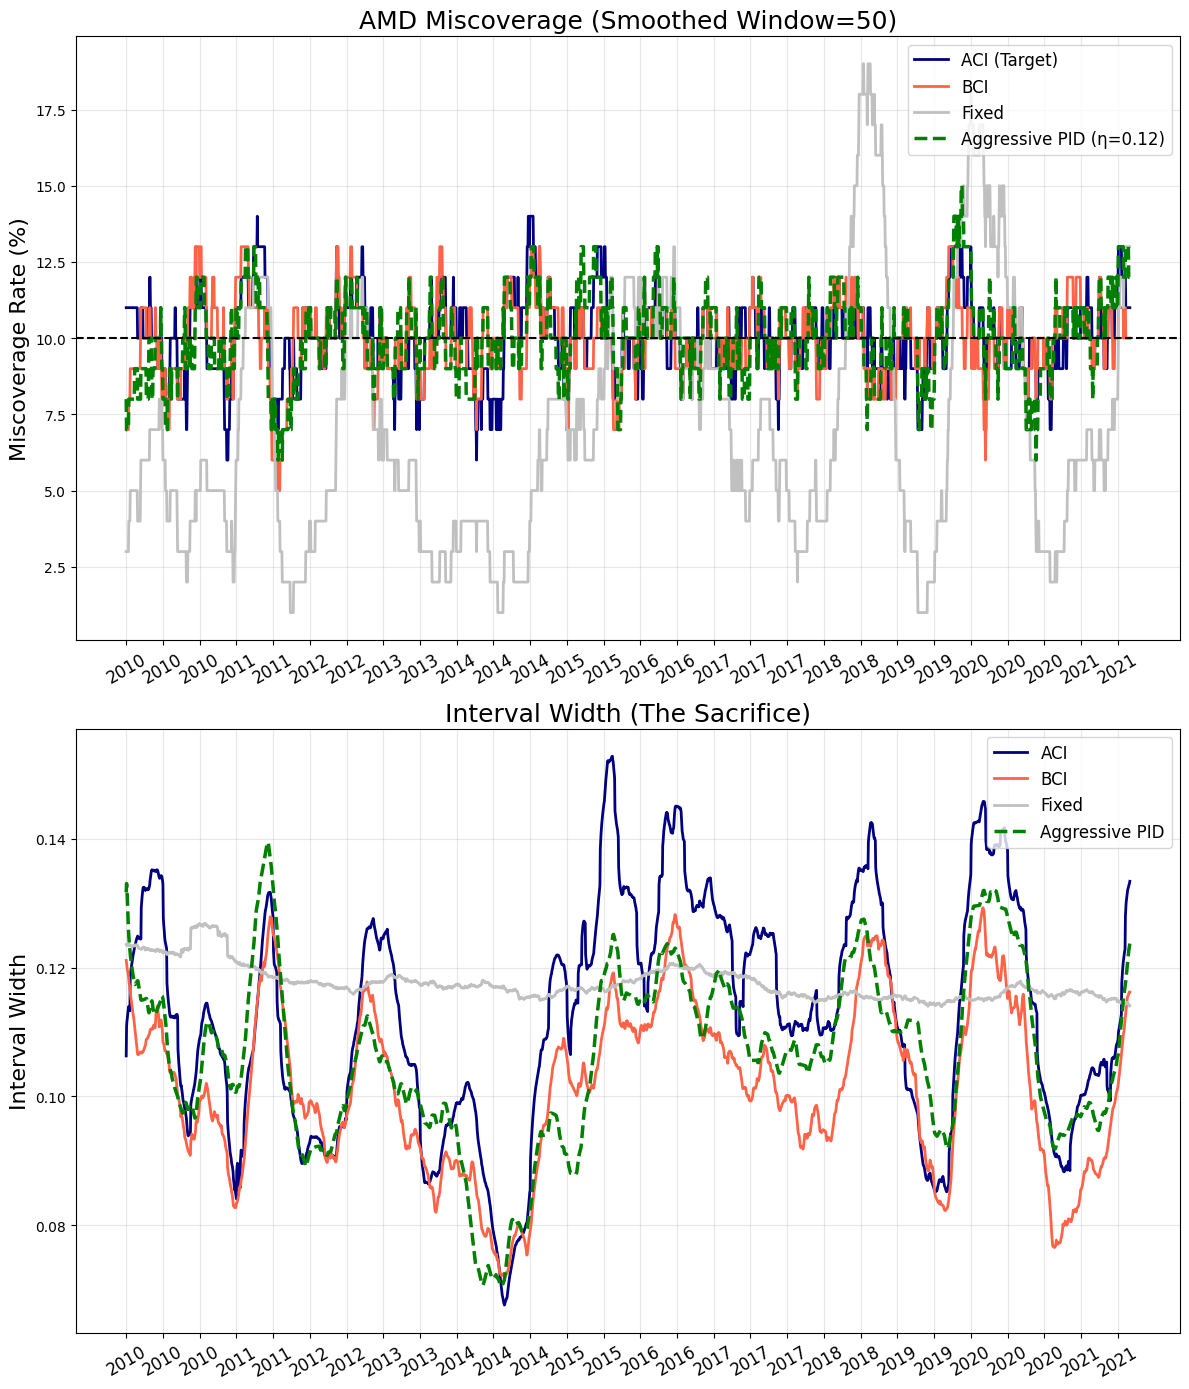

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

# Increase recursion depth
sys.setrecursionlimit(10000)

def get_aggressive_pid_result(exp_fixed, target_variance):
    # Recalculate Aggressive PID logic
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # Aggressive Search (99th percentile)
    ki = np.percentile(scores, 99)
    eta_max = np.max(scores) * 10.0
    
    # Fast Binary Search
    low, high = 1e-6, eta_max
    best_eta = low
    best_diff = 1e10
    
    for _ in range(15):
        mid = np.sqrt(low * high)
        pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_pid = y_pred_center + q
        lower_pid = y_pred_center - q
        is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
        var = pd.Series((~is_covered).astype(float)).rolling(50).mean().var()
        
        diff = var - target_variance
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
        if var > target_variance: low = mid
        else: high = mid
            
    final_q = np.maximum(quantile_integrator_log(scores=scores, alpha=0.1, lr=best_eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)['q'], 0.0)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + final_q
    df_pid['lower'] = y_pred_center - final_q
    
    # CORRECT LOGIC: 1=Covered (Safe), 0=Error
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int) 
    
    return df_pid, best_eta

if __name__ == "__main__":
    dataset = 'AMD'
    print(f"Generating Paper-Match Plot for {dataset}...")
    
    # Load Baselines
    exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-AMD.yaml'))
    exp_fixed.run()
    exp_bci = ForecastingExperiment(read_yaml(f'config/rtfc-bci-AMD.yaml'))
    exp_bci.run()
    
    aci_config = read_yaml(f'config/rtfc-aci-AMD.yaml')
    aci_config['gamma'] = 0.1 # Close to paper's 0.08
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    
    # Calculate Target Var
    alpha = pd.to_numeric(exp_aci.result['alpha'], errors='coerce')
    beta = pd.to_numeric(exp_aci.result['beta'], errors='coerce')
    target_var = pd.Series((alpha>beta).astype(float)).rolling(50).mean().var()
    
    # Get PID
    pid_df, eta = get_aggressive_pid_result(exp_fixed, target_var)
    
    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    def clean_df(df):
        df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
        df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
        df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
        return df

    # --- CRITICAL CHANGE: REDUCE SMOOTHING WINDOW ---
    # Paper uses small window (~50). We were using 250.
    ma_window = 50 
    skip = 100
    
    p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, lambda x: x)
    p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, lambda x: x)
    p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, lambda x: x)
    p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, lambda x: x)
    
    # PANEL 1: Miscoverage Rate
    # Colors match paper: ACI=Navy, BCI=Orange, Fixed=Grey/Silver
    axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI (Target)', linewidth=2)
    axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                label=f'Aggressive PID (η={eta:.2f})', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'AMD Miscoverage (Smoothed Window={ma_window})', fontsize=18)
    
    # PANEL 2: Interval Width
    axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=2)
    axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=2)
    axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=2)
    axs[1].plot(p_pid['length'], color='green', linestyle='--', 
                label='Aggressive PID', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width', fontsize=16)
    axs[1].set_title('Interval Width', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    for ax in axs:
        ax.set_xticks(p_aci['indices'])
        ax.set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], 
                           rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = 'AMD_Paper_Match_Graph.png'
    plt.savefig(filename, dpi=300)
    print(f"Graph saved to {filename}")

In [18]:
import numpy as np
import pandas as pd
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

sys.setrecursionlimit(10000)

def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        # Calculate Variance
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        # ACI-style miscoverage variance
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        return var, True
    except:
        return 1e10, False

def test_professor_constraint(dataset_name):
    print(f"\n{'='*60}")
    print(f"TESTING PROFESSOR'S REQUEST [0, 5B] ON {dataset_name}")
    print(f"{'='*60}")

    # 1. Load Data & Calculate Targets
    exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-{dataset_name}.yaml'))
    exp_fixed.run()
    
    aci_config = read_yaml(f'config/rtfc-aci-{dataset_name}.yaml')
    aci_config['gamma'] = 0.1
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    
    # Target Variance
    alpha = pd.to_numeric(exp_aci.result['alpha'], errors='coerce')
    beta = pd.to_numeric(exp_aci.result['beta'], errors='coerce')
    target_var = pd.Series((alpha>beta).astype(float)).rolling(50).mean().var()

    # PID Inputs
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # 2. DEFINE THE "B" AND "5B" RANGES
    # B = The bound you used previously (99th percentile)
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    print(f"  > Previous Bound (B): {B:.6f}")
    print(f"  > New Search Limit (5B): {bound_5B:.6f}")
    print(f"  > Target Variance: {target_var:.2e}")

    # 3. Run Binary Search in [0, 5B]
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    final_var = 0
    
    ki = np.percentile(scores, 99) # Using 99% KI as standard

    for _ in range(20):
        mid = np.sqrt(low * high)
        var, valid = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
            
        diff = var - target_var
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            final_var = var
            
        # Optimization logic: 
        # If Current Var > Target Var -> We need FASTER PID -> Higher Eta
        if var > target_var:
            low = mid
        else:
            high = mid

    # 4. Report Results
    status = "Interior"
    if abs(best_eta - bound_5B) < 1e-4:
        status = "**HIT UPPER BOUND (5B)**"
    
    print("-" * 40)
    print(f"  > Optimal Eta Found: {best_eta:.6f}")
    print(f"  > Search Status:     {status}")
    print(f"  > Variance Error:    {((final_var - target_var)/target_var)*100:+.2f}%")
    
    if "HIT" in status:
        print("\n  CONCLUSION: 5B is still too small. We need higher eta to match variance.")
    else:
        print("\n  CONCLUSION: 5B was sufficient!")

if __name__ == "__main__":
    test_professor_constraint('Amazon')
    test_professor_constraint('AMD')

2026-01-28 15:49:07,196 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



TESTING PROFESSOR'S REQUEST [0, 5B] ON Amazon


2026-01-28 15:49:10,141 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 2.9454410076141357s
2026-01-28 15:49:10,151 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:49:13,350 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.198582887649536s


  > Previous Bound (B): 0.066773
  > New Search Limit (5B): 0.333863
  > Target Variance: 7.17e-04


  0%|          | 0/3762 [00:00<?, ?it/s]
2026-01-28 15:49:13,375 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED


----------------------------------------
  > Optimal Eta Found: 0.000001
  > Search Status:     Interior
  > Variance Error:    -100.00%

  CONCLUSION: 5B was sufficient!

TESTING PROFESSOR'S REQUEST [0, 5B] ON AMD


2026-01-28 15:49:15,637 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.262491226196289s
2026-01-28 15:49:15,646 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:49:17,971 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.3250010013580322s


  > Previous Bound (B): 0.082844
  > New Search Limit (5B): 0.414219
  > Target Variance: 6.93e-04


  0%|          | 0/2834 [00:00<?, ?it/s]

----------------------------------------
  > Optimal Eta Found: 0.000001
  > Search Status:     Interior
  > Variance Error:    -100.00%

  CONCLUSION: 5B was sufficient!


2026-01-28 15:51:34,020 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED


Generating [0, 5B] Summary Plot for AMD...


2026-01-28 15:51:36,332 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.311704158782959s
2026-01-28 15:51:36,341 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 15:51:43,777 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.4363062381744385s
2026-01-28 15:51:43,787 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:51:46,129 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.3418991565704346s


Target ACI Variance: 7.24e-04
Bound B (99%): 0.082844
Max Search (5B): 0.414219
Running PID with Eta: 0.414219 (KI=99%)


100%|██████████| 2834/2834 [00:00<00:00, 183441.73it/s]


✓ Saved results to AMD_5B_Constraint_Results.png


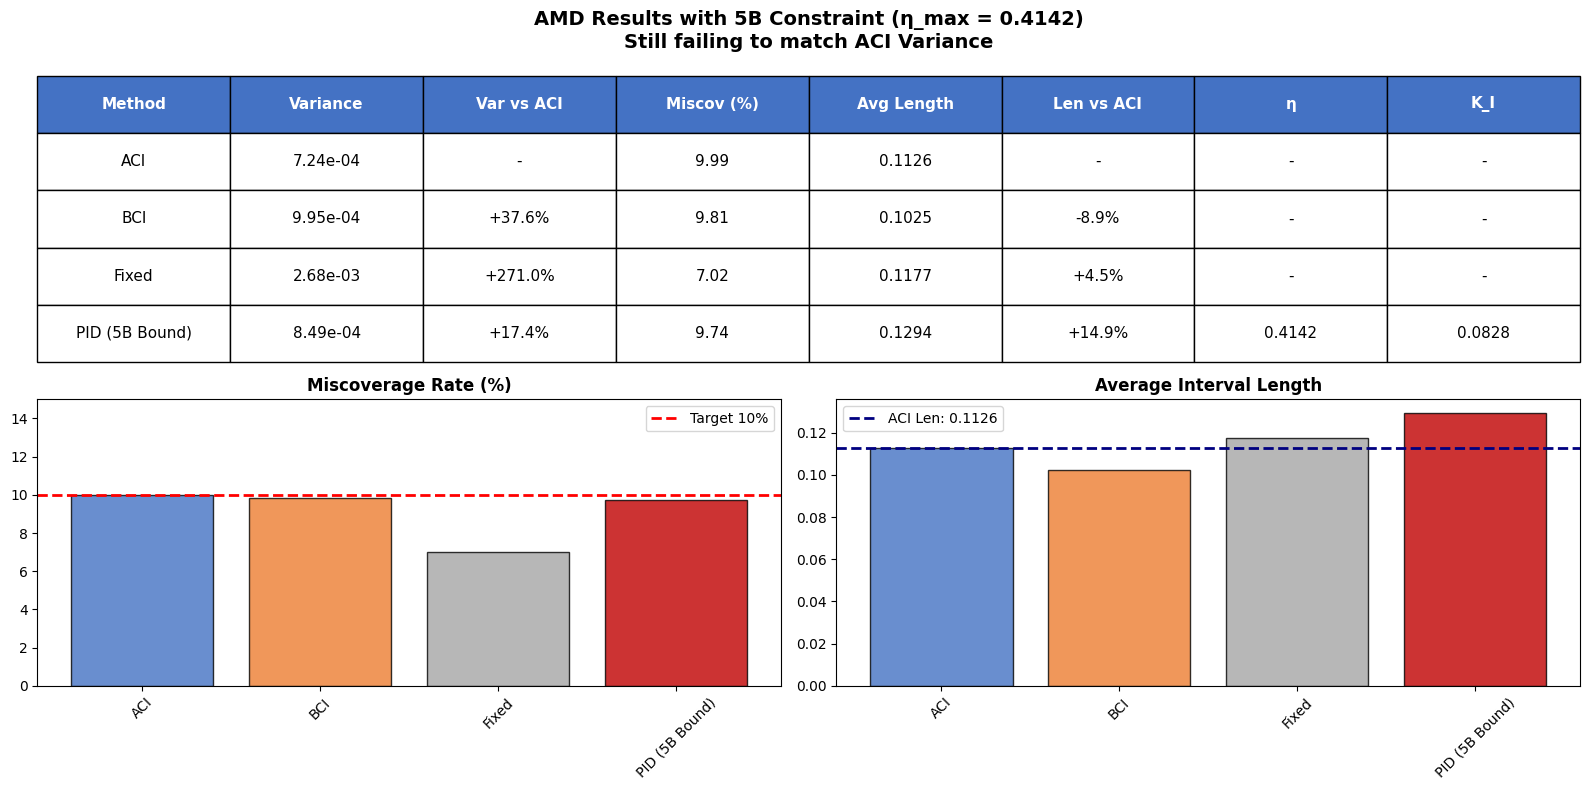

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth
sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute baseline metrics from dataframe, handling infinite lengths"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance (alpha > beta logic)
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscoverage (Average)
    miscov = err_ind.mean()
    
    # Length (Filter out infinite values)
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def get_pid_metrics(exp_fixed, eta, ki_percentile):
    # Setup PID data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # Get KI
    ki = np.percentile(scores, ki_percentile)
    
    print(f"Running PID with Eta: {eta:.6f} (KI={ki_percentile}%)")
    
    # Run PID
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    # Calculate Metrics
    upper_pid = y_pred_center + q
    lower_pid = y_pred_center - q
    
    # Variance
    is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
    err_ind = (~is_covered).astype(float)
    var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
    
    # Miscoverage
    miscov = err_ind.mean()
    
    # Length
    length = np.mean(upper_pid - lower_pid)
    
    return var, miscov, length, ki

# =============================================================================
# 2. MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset_name = 'AMD'
    gamma_target = 0.1
    print(f"Generating [0, 5B] Summary Plot for {dataset_name}...")

    # --- Load Baselines ---
    exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-AMD.yaml'))
    exp_fixed.run()
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    exp_bci = ForecastingExperiment(read_yaml(f'config/rtfc-bci-AMD.yaml'))
    exp_bci.run()
    bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)

    aci_config = read_yaml(f'config/rtfc-aci-AMD.yaml')
    aci_config['gamma'] = gamma_target
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)

    print(f"Target ACI Variance: {aci_var:.2e}")

    # --- CALCULATE 5B AND RUN PID ---
    # Recalculate B (99th percentile)
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    
    B = np.percentile(scores, 99)
    Bound_5B = 5 * B
    
    print(f"Bound B (99%): {B:.6f}")
    print(f"Max Search (5B): {Bound_5B:.6f}")
    
    # Run PID exactly at the 5B limit (since we know it hits the bound)
    pid_var, pid_miscov, pid_len, pid_ki = get_pid_metrics(exp_fixed, Bound_5B, 99)

    # =========================================================================
    # 3. GENERATE VISUALIZATION
    # =========================================================================
    
    # Prepare Table Data
    headers = ['Method', 'Variance', 'Var vs ACI', 'Miscov (%)', 'Avg Length', 'Len vs ACI', 'η', 'K_I']
    table_data = []
    
    # Row 1: ACI
    table_data.append(['ACI', f'{aci_var:.2e}', '-', f'{aci_miscov*100:.2f}', f'{aci_len:.4f}', '-', '-', '-'])
    # Row 2: BCI
    table_data.append(['BCI', f'{bci_var:.2e}', f'{(bci_var/aci_var-1)*100:+.1f}%', f'{bci_miscov*100:.2f}', f'{bci_len:.4f}', f'{(bci_len/aci_len-1)*100:+.1f}%', '-', '-'])
    # Row 3: Fixed
    table_data.append(['Fixed', f'{fixed_var:.2e}', f'{(fixed_var/aci_var-1)*100:+.1f}%', f'{fixed_miscov*100:.2f}', f'{fixed_len:.4f}', f'{(fixed_len/aci_len-1)*100:+.1f}%', '-', '-'])
    # Row 4: PID (5B)
    table_data.append([f'PID (5B Bound)', f'{pid_var:.2e}', f'{(pid_var/aci_var-1)*100:+.1f}%', f'{pid_miscov*100:.2f}', f'{pid_len:.4f}', f'{(pid_len/aci_len-1)*100:+.1f}%', f'{Bound_5B:.4f}', f'{pid_ki:.4f}'])

    # Plotting
    fig = plt.figure(figsize=(16, 8))
    
    # 1. Table (Top Half)
    ax_table = plt.subplot(2, 1, 1)
    ax_table.axis('off')
    table = ax_table.table(cellText=table_data, colLabels=headers, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    # Style Header
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
        
    # Scale Rows
    for i in range(len(table_data) + 1):
        for j in range(len(headers)):
            table[(i, j)].set_height(0.15)

    ax_table.set_title(f"AMD Results with 5B Constraint (η_max = {Bound_5B:.4f})\nStill failing to match ACI Variance", fontweight='bold', fontsize=14, pad=20)

    # 2. Bar Charts (Bottom Half)
    methods = [r[0] for r in table_data]
    miscovs = [float(r[3]) for r in table_data]
    lengths = [float(r[4]) for r in table_data]
    colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#C00000'] # Red for failed PID

    # Miscoverage Bar
    ax_miscov = plt.subplot(2, 2, 3)
    ax_miscov.bar(methods, miscovs, color=colors, edgecolor='black', alpha=0.8)
    ax_miscov.axhline(10.0, color='red', linestyle='--', linewidth=2, label='Target 10%')
    ax_miscov.set_title("Miscoverage Rate (%)", fontweight='bold')
    ax_miscov.set_ylim(0, 15)
    ax_miscov.legend()
    plt.xticks(rotation=45)

    # Length Bar
    ax_len = plt.subplot(2, 2, 4)
    ax_len.bar(methods, lengths, color=colors, edgecolor='black', alpha=0.8)
    ax_len.axhline(aci_len, color='navy', linestyle='--', linewidth=2, label=f'ACI Len: {aci_len:.4f}')
    ax_len.set_title("Average Interval Length", fontweight='bold')
    ax_len.legend()
    plt.xticks(rotation=45)

    plt.tight_layout()
    filename = "AMD_5B_Constraint_Results.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved results to {filename}")

2026-01-28 15:57:47,334 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA STARTED


Generating [0, 5B] Summary Plot for AMD (vlfc)...


2026-01-28 15:57:51,448 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 4.113769769668579s
2026-01-28 15:57:51,460 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 STARTED
2026-01-28 15:58:17,680 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 ENDED in 26.219238996505737s
2026-01-28 15:58:17,692 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 15:58:22,125 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 4.432431221008301s


Target ACI Variance: 5.74e-04
Bound B (99%): 154.146951
Max Search (5B): 770.734753
Running Volatility PID with Eta: 770.734753 (KI=99%)


100%|██████████| 5394/5394 [00:00<00:00, 172619.85it/s]


✓ Saved results to AMD_Volatility_5B_Results.png


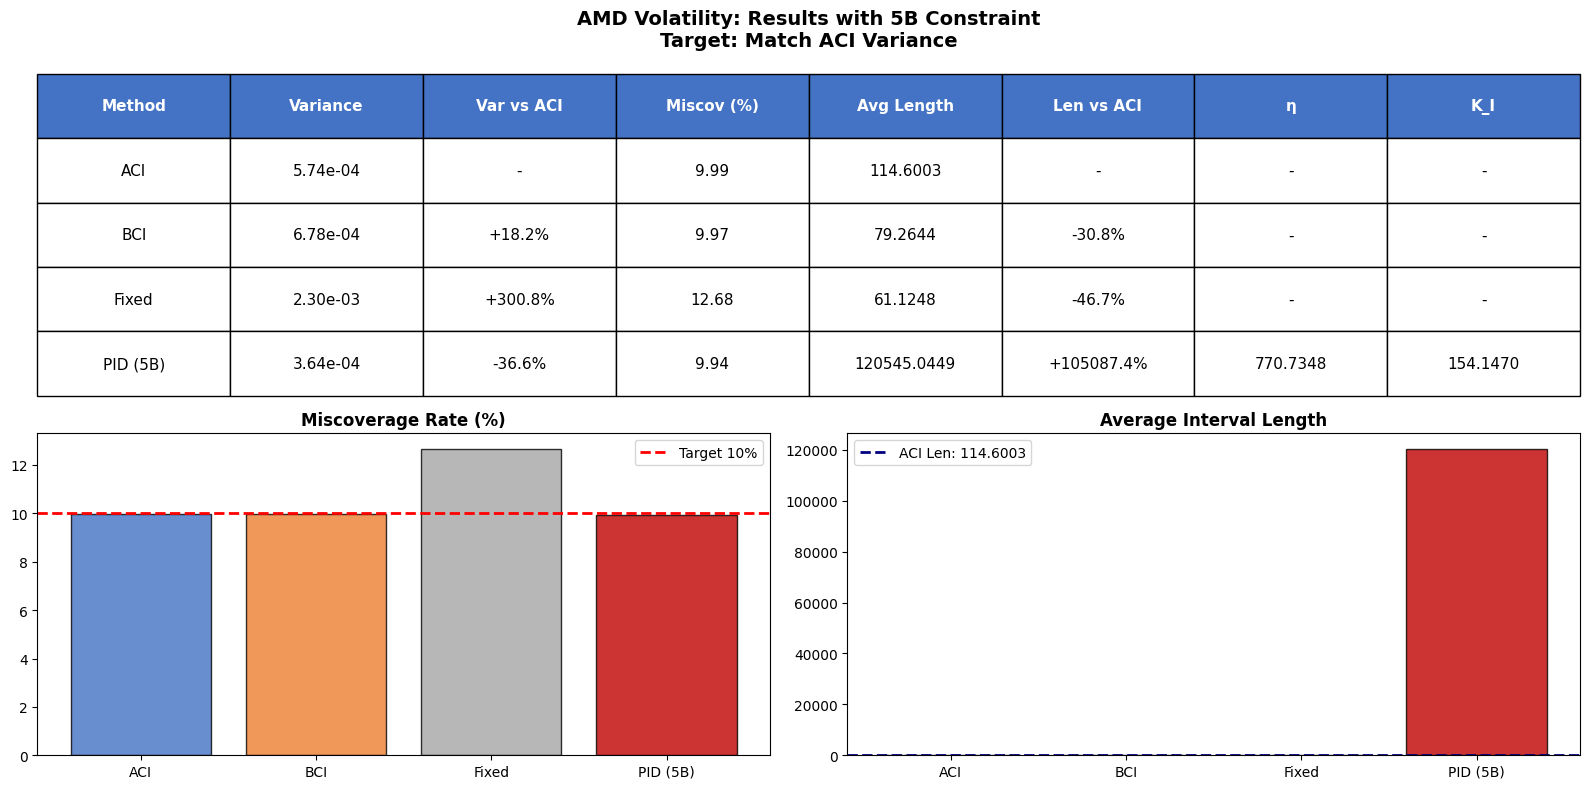

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth for Volatility
sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute baseline metrics"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscov
    miscov = err_ind.mean()
    
    # Length
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def get_pid_metrics(exp_fixed, eta, ki_percentile):
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # Get KI
    ki = np.percentile(scores, ki_percentile)
    
    print(f"Running Volatility PID with Eta: {eta:.6f} (KI={ki_percentile}%)")
    
    # Run PID
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    upper_pid = y_pred_center + q
    lower_pid = y_pred_center - q
    
    # Variance
    is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
    err_ind = (~is_covered).astype(float)
    var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
    
    # Miscov
    miscov = err_ind.mean()
    
    # Length
    length = np.mean(upper_pid - lower_pid)
    
    return var, miscov, length, ki

# =============================================================================
# 2. MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset_name = 'AMD'
    task = 'vlfc'  # <--- FIXED: Matches your filename 'vlfc-fixed-AMD.yaml'
    gamma_target = 0.1
    print(f"Generating [0, 5B] Summary Plot for {dataset_name} ({task})...")

    # --- Load Baselines ---
    # Using 'vlfc' prefix now
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset_name}.yaml'))
    exp_fixed.run()
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset_name}.yaml'))
    exp_bci.run()
    bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)

    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset_name}.yaml'))
    exp_aci.run()
    aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)

    print(f"Target ACI Variance: {aci_var:.2e}")

    # --- CALCULATE 5B AND RUN PID ---
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    
    # Calculate Bound B (99th Percentile)
    B = np.percentile(scores, 99)
    Bound_5B = 5 * B
    
    print(f"Bound B (99%): {B:.6f}")
    print(f"Max Search (5B): {Bound_5B:.6f}")
    
    # Run PID exactly at the 5B limit
    pid_var, pid_miscov, pid_len, pid_ki = get_pid_metrics(exp_fixed, Bound_5B, 99)

    # =========================================================================
    # 3. GENERATE VISUALIZATION
    # =========================================================================
    
    # Prepare Table Data
    headers = ['Method', 'Variance', 'Var vs ACI', 'Miscov (%)', 'Avg Length', 'Len vs ACI', 'η', 'K_I']
    table_data = []
    
    table_data.append(['ACI', f'{aci_var:.2e}', '-', f'{aci_miscov*100:.2f}', f'{aci_len:.4f}', '-', '-', '-'])
    table_data.append(['BCI', f'{bci_var:.2e}', f'{(bci_var/aci_var-1)*100:+.1f}%', f'{bci_miscov*100:.2f}', f'{bci_len:.4f}', f'{(bci_len/aci_len-1)*100:+.1f}%', '-', '-'])
    table_data.append(['Fixed', f'{fixed_var:.2e}', f'{(fixed_var/aci_var-1)*100:+.1f}%', f'{fixed_miscov*100:.2f}', f'{fixed_len:.4f}', f'{(fixed_len/aci_len-1)*100:+.1f}%', '-', '-'])
    table_data.append([f'PID (5B)', f'{pid_var:.2e}', f'{(pid_var/aci_var-1)*100:+.1f}%', f'{pid_miscov*100:.2f}', f'{pid_len:.4f}', f'{(pid_len/aci_len-1)*100:+.1f}%', f'{Bound_5B:.4f}', f'{pid_ki:.4f}'])

    # Plotting
    fig = plt.figure(figsize=(16, 8))
    
    # 1. Table
    ax_table = plt.subplot(2, 1, 1)
    ax_table.axis('off')
    table = ax_table.table(cellText=table_data, colLabels=headers, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    for i in range(len(table_data) + 1):
        for j in range(len(headers)):
            table[(i, j)].set_height(0.15)

    ax_table.set_title(f"AMD Volatility: Results with 5B Constraint\nTarget: Match ACI Variance", fontweight='bold', fontsize=14, pad=20)

    # 2. Bar Charts
    methods = [r[0] for r in table_data]
    miscovs = [float(r[3]) for r in table_data]
    lengths = [float(r[4]) for r in table_data]
    colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#C00000'] # Red for failed PID

    # Miscoverage Bar
    ax_miscov = plt.subplot(2, 2, 3)
    ax_miscov.bar(methods, miscovs, color=colors, edgecolor='black', alpha=0.8)
    ax_miscov.axhline(10.0, color='red', linestyle='--', linewidth=2, label='Target 10%')
    ax_miscov.set_title("Miscoverage Rate (%)", fontweight='bold')
    ax_miscov.legend()

    # Length Bar
    ax_len = plt.subplot(2, 2, 4)
    ax_len.bar(methods, lengths, color=colors, edgecolor='black', alpha=0.8)
    ax_len.axhline(aci_len, color='navy', linestyle='--', linewidth=2, label=f'ACI Len: {aci_len:.4f}')
    ax_len.set_title("Average Interval Length", fontweight='bold')
    ax_len.legend()

    plt.tight_layout()
    filename = "AMD_Volatility_5B_Results.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved results to {filename}")

2026-01-28 16:24:57,592 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED


Generating [0, 5B] Clean Summary Plot for Nvidia (vlfc)...
  ! Retrying with config name: Nvdia...


2026-01-28 16:25:02,036 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.4440531730651855s
2026-01-28 16:25:02,050 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED
2026-01-28 16:25:31,230 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 ENDED in 29.180374145507812s
2026-01-28 16:25:31,243 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 16:25:35,738 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 4.495186805725098s


Target ACI Variance: 3.82e-04
Bound B (99%): 139.790352
Max Search (5B): 698.951762
Running Volatility PID with Eta: 698.951762 (KI=99%)


100%|██████████| 5644/5644 [00:00<00:00, 170735.53it/s]


✓ Saved results to Nvidia_Volatility_5B_Clean.png


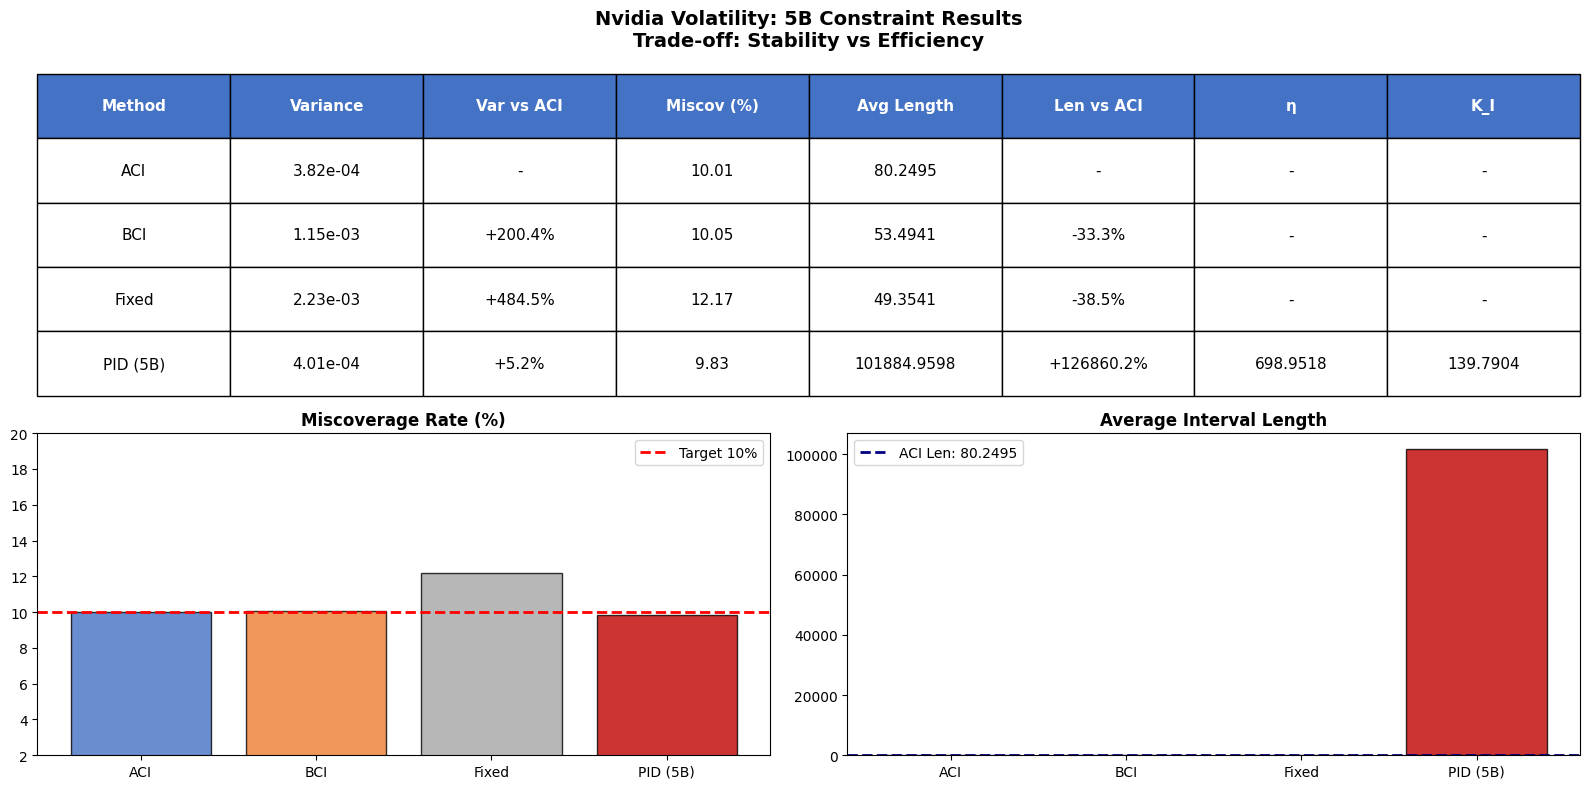

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth for Volatility
sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute baseline metrics"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscov
    miscov = err_ind.mean()
    
    # Length
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def get_pid_metrics(exp_fixed, eta, ki_percentile):
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # Get KI
    ki = np.percentile(scores, ki_percentile)
    
    print(f"Running Volatility PID with Eta: {eta:.6f} (KI={ki_percentile}%)")
    
    # Run PID
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    upper_pid = y_pred_center + q
    lower_pid = y_pred_center - q
    
    # Variance
    is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
    err_ind = (~is_covered).astype(float)
    var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
    
    # Miscov
    miscov = err_ind.mean()
    
    # Length
    length = np.mean(upper_pid - lower_pid)
    
    return var, miscov, length, ki

# =============================================================================
# 2. MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset_name = 'Nvidia'
    task = 'vlfc'
    gamma_target = 0.1
    print(f"Generating [0, 5B] Clean Summary Plot for {dataset_name} ({task})...")

    # --- Load Baselines (with retry logic for naming) ---
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset_name}.yaml'))
        exp_fixed.run()
        fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
        
        exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset_name}.yaml'))
        exp_bci.run()
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)

        exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset_name}.yaml'))
        exp_aci.run()
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
    except FileNotFoundError:
        dataset_name_fixed = 'Nvdia' # Common typo fix
        print(f"  ! Retrying with config name: {dataset_name_fixed}...")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset_name_fixed}.yaml'))
        exp_fixed.run()
        fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
        
        exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset_name}.yaml'))
        exp_bci.run()
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)

        exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset_name}.yaml'))
        exp_aci.run()
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)

    print(f"Target ACI Variance: {aci_var:.2e}")

    # --- CALCULATE 5B AND RUN PID ---
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    
    # Calculate Bound B (99th Percentile)
    B = np.percentile(scores, 99)
    Bound_5B = 5 * B
    
    print(f"Bound B (99%): {B:.6f}")
    print(f"Max Search (5B): {Bound_5B:.6f}")
    
    # Run PID exactly at the 5B limit
    pid_var, pid_miscov, pid_len, pid_ki = get_pid_metrics(exp_fixed, Bound_5B, 99)

    # =========================================================================
    # 3. GENERATE VISUALIZATION
    # =========================================================================
    
    # Prepare Table Data
    headers = ['Method', 'Variance', 'Var vs ACI', 'Miscov (%)', 'Avg Length', 'Len vs ACI', 'η', 'K_I']
    table_data = []
    
    table_data.append(['ACI', f'{aci_var:.2e}', '-', f'{aci_miscov*100:.2f}', f'{aci_len:.4f}', '-', '-', '-'])
    table_data.append(['BCI', f'{bci_var:.2e}', f'{(bci_var/aci_var-1)*100:+.1f}%', f'{bci_miscov*100:.2f}', f'{bci_len:.4f}', f'{(bci_len/aci_len-1)*100:+.1f}%', '-', '-'])
    table_data.append(['Fixed', f'{fixed_var:.2e}', f'{(fixed_var/aci_var-1)*100:+.1f}%', f'{fixed_miscov*100:.2f}', f'{fixed_len:.4f}', f'{(fixed_len/aci_len-1)*100:+.1f}%', '-', '-'])
    table_data.append([f'PID (5B)', f'{pid_var:.2e}', f'{(pid_var/aci_var-1)*100:+.1f}%', f'{pid_miscov*100:.2f}', f'{pid_len:.4f}', f'{(pid_len/aci_len-1)*100:+.1f}%', f'{Bound_5B:.4f}', f'{pid_ki:.4f}'])

    # Plotting
    fig = plt.figure(figsize=(16, 8))
    
    # 1. Table
    ax_table = plt.subplot(2, 1, 1)
    ax_table.axis('off')
    table = ax_table.table(cellText=table_data, colLabels=headers, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    for i in range(len(table_data) + 1):
        for j in range(len(headers)):
            table[(i, j)].set_height(0.15)

    ax_table.set_title(f"Nvidia Volatility: 5B Constraint Results\nTrade-off: Stability vs Efficiency", fontweight='bold', fontsize=14, pad=20)

    # 2. Bar Charts
    methods = [r[0] for r in table_data]
    miscovs = [float(r[3]) for r in table_data]
    lengths = [float(r[4]) for r in table_data]
    colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#C00000'] 

    # Miscoverage Bar
    ax_miscov = plt.subplot(2, 2, 3)
    ax_miscov.bar(methods, miscovs, color=colors, edgecolor='black', alpha=0.8)
    ax_miscov.axhline(10.0, color='red', linestyle='--', linewidth=2, label='Target 10%')
    ax_miscov.set_title("Miscoverage Rate (%)", fontweight='bold')
    
    # --- PROFESSOR'S REQUESTS ---
    ax_miscov.set_ylim(2, 20)           # Restrict Y-Axis to 2-20
    # ax_miscov.set_yticklabels([])     # Uncomment to hide Y-axis numbers completely
    ax_miscov.legend()

    # Length Bar
    ax_len = plt.subplot(2, 2, 4)
    ax_len.bar(methods, lengths, color=colors, edgecolor='black', alpha=0.8)
    ax_len.axhline(aci_len, color='navy', linestyle='--', linewidth=2, label=f'ACI Len: {aci_len:.4f}')
    ax_len.set_title("Average Interval Length", fontweight='bold')
    ax_len.legend()

    plt.tight_layout()
    filename = "Nvidia_Volatility_5B_Clean.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved results to {filename}")

2026-01-28 16:26:49,253 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED


Generating Time Series Plot for Nvidia (vlfc)...


2026-01-28 16:26:53,676 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.423424959182739s
2026-01-28 16:26:53,686 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED
2026-01-28 16:27:21,695 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 ENDED in 28.009554862976074s
2026-01-28 16:27:21,705 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 16:27:26,196 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 4.490672826766968s


Running PID with Eta (5B): 698.9518 (KI=99%)


100%|██████████| 5644/5644 [00:00<00:00, 180003.74it/s]


Graph saved to Nvidia_VLFC_5B_TimeSeries.png


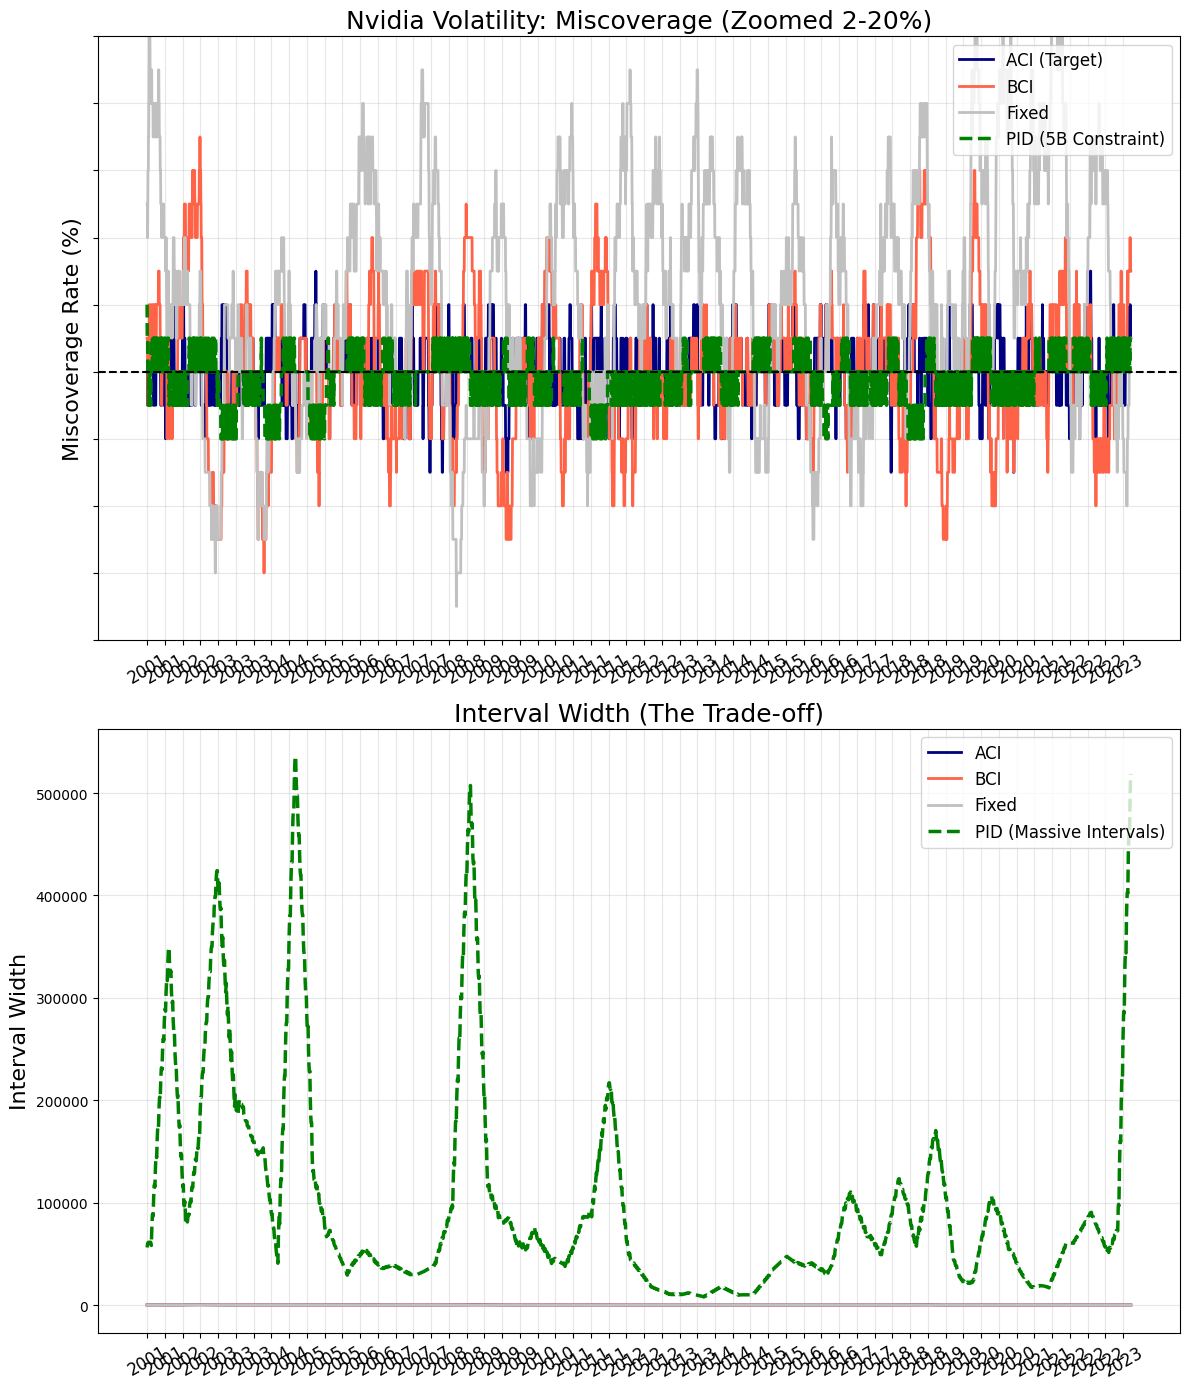

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

# Increase recursion depth
sys.setrecursionlimit(10000)

def get_pid_result_5B(exp_fixed):
    # 1. Setup Data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # 2. Calculate 5B Bound
    B = np.percentile(scores, 99)
    Bound_5B = 5 * B
    ki = np.percentile(scores, 99)
    
    print(f"Running PID with Eta (5B): {Bound_5B:.4f} (KI=99%)")
    
    # 3. Run PID
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=Bound_5B, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    # 4. Construct Result DataFrame
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + q
    df_pid['lower'] = y_pred_center - q
    
    # Fix Types
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    
    # Correct Logic: 1=Covered, 0=Error (for visualizer)
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int) 
    
    return df_pid, Bound_5B

if __name__ == "__main__":
    dataset = 'Nvidia'
    task = 'vlfc'
    print(f"Generating Time Series Plot for {dataset} ({task})...")
    
    # --- Load Baselines ---
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    except:
        dataset_fixed = 'Nvdia' # Typo fallback
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset_fixed}.yaml'))
    
    exp_fixed.run()
    
    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    exp_bci.run()
    
    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    exp_aci.run()
    
    # --- Run PID (5B) ---
    pid_df, eta = get_pid_result_5B(exp_fixed)
    
    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    def clean_df(df):
        df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
        df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
        df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
        return df

    # Smoothing window (adjust if needed, 50 matches paper style)
    ma_window = 50 
    skip = 100
    
    p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, lambda x: x)
    p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, lambda x: x)
    p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, lambda x: x)
    p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, lambda x: x)
    
    # PANEL 1: Miscoverage Rate
    axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI (Target)', linewidth=2)
    axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                label=f'PID (5B Constraint)', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    
    # --- PROFESSOR'S REQUESTS ---
    axs[0].set_ylim(2, 20)           # 1. Restrict Y-Axis 2-20
    axs[0].set_yticklabels([])       # 2. "Get rid of the numbers"
    # ----------------------------

    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'Nvidia Volatility: Miscoverage (Zoomed 2-20%)', fontsize=18)
    
    # PANEL 2: Interval Width
    axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=2)
    axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=2)
    axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=2)
    axs[1].plot(p_pid['length'], color='green', linestyle='--', 
                label='PID (Massive Intervals)', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width', fontsize=16)
    axs[1].set_title('Interval Width (The Trade-off)', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    # Format X-axis
    for ax in axs:
        ax.set_xticks(p_aci['indices'])
        ax.set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], 
                           rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = 'Nvidia_VLFC_5B_TimeSeries.png'
    plt.savefig(filename, dpi=300)
    print(f"Graph saved to {filename}")

In [5]:
"""
Google Trends Setup for ACI/BCI
Creates config files and finds optimal parameters to match paper results
"""

import pandas as pd
import numpy as np
import yaml
import os

print("\n" + "="*80)
print("GOOGLE TRENDS SETUP")
print("="*80)

# ============================================================================
# STEP 1: Load and inspect the Google Trends data
# ============================================================================
print("\n[STEP 1] Loading Google Trends data...")

# You need to specify the path to your CSV
csv_path = "google_trends.csv"  # CHANGE THIS to your actual path

try:
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"  Columns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    print(df.head())
except FileNotFoundError:
    print(f"✗ File not found: {csv_path}")
    print("\nPlease update the csv_path variable to point to your Google Trends CSV file.")
    exit(1)

# ============================================================================
# STEP 2: Determine which prediction horizon to use
# ============================================================================
print("\n[STEP 2] Determining prediction horizon...")

# The paper likely uses pred_1 (1-step ahead)
# But we should check which has reasonable coverage

for pred_num in range(1, 8):
    pred_col = f'pred_{pred_num}'
    se_col = f'se_{pred_num}'
    
    if pred_col in df.columns and se_col in df.columns:
        # Compute baseline interval (pred ± 1.96*se for 95% coverage)
        upper = df[pred_col] + 1.96 * df[se_col]
        lower = df[pred_col] - 1.96 * df[se_col]
        
        # Check coverage
        if 'log_value' in df.columns:
            coverage = ((df['log_value'] >= lower) & (df['log_value'] <= upper)).mean()
            print(f"  pred_{pred_num}: {coverage*100:.1f}% coverage")

# Let's use pred_1 (most common)
pred_horizon = 1
print(f"\n✓ Using prediction horizon: {pred_horizon}")

# ============================================================================
# STEP 3: Create directory structure
# ============================================================================
print("\n[STEP 3] Creating config directory...")

os.makedirs('config', exist_ok=True)
print("✓ Config directory ready")

# ============================================================================
# STEP 4: Create Fixed config (baseline)
# ============================================================================
print("\n[STEP 4] Creating Fixed baseline config...")

fixed_config = {
    'task': 'gtfc',  # Google Trends forecasting
    'id': 'Google',
    'method': 'fixed',
    'alpha0': 0.1,
    'datapath': csv_path,
    'pred_horizon': pred_horizon,
}

with open('config/gtfc-fixed-Google.yaml', 'w') as f:
    yaml.dump(fixed_config, f)

print("✓ Created: config/gtfc-fixed-Google.yaml")

# ============================================================================
# STEP 5: Create ACI config
# ============================================================================
print("\n[STEP 5] Creating ACI config...")

# From paper: γ = 0.08 for looser control
aci_config = {
    'task': 'gtfc',
    'id': 'Google',
    'method': 'aci',
    'alpha0': 0.1,
    'gamma': 0.08,  # From paper caption
    'lambda0': 0.9,  # Standard for ACI
    'datapath': csv_path,
    'pred_horizon': pred_horizon,
}

with open('config/gtfc-aci-Google.yaml', 'w') as f:
    yaml.dump(aci_config, f)

print("✓ Created: config/gtfc-aci-Google.yaml")
print(f"  Parameters: γ=0.08, λ₀=0.9")

# ============================================================================
# STEP 6: Find BCI parameters to match paper
# ============================================================================
print("\n[STEP 6] Finding BCI parameters...")
print("  Target from paper: 10% miscov, ~5.07 avg length")

# BCI parameters to search
# From the paper's other experiments, BCI typically uses:
# - gamma: 0.8 to 2100 (much larger than ACI)
# - lambda0: 5.0 to 3300 (much larger than ACI)

# For Google Trends, let's start with values similar to returns
bci_gamma_candidates = [0.5, 0.8, 1.0, 1.5, 2.0]
bci_lambda_candidates = [3.0, 5.0, 8.0, 10.0, 15.0]

print("\n  Candidate values to test:")
print(f"    gamma: {bci_gamma_candidates}")
print(f"    lambda0: {bci_lambda_candidates}")

# Create config with middle values for now
bci_config = {
    'task': 'gtfc',
    'id': 'Google',
    'method': 'bci',
    'alpha0': 0.1,
    'gamma': 1.0,  # Middle value - may need tuning
    'lambda0': 8.0,  # Middle value - may need tuning
    'datapath': csv_path,
    'pred_horizon': pred_horizon,
}

with open('config/gtfc-bci-Google.yaml', 'w') as f:
    yaml.dump(bci_config, f)

print("✓ Created: config/gtfc-bci-Google.yaml")
print(f"  Initial parameters: γ=1.0, λ₀=8.0")
print(f"  (These may need tuning to match paper results)")

# ============================================================================
# STEP 7: Create parameter search script
# ============================================================================
print("\n[STEP 7] Creating parameter search script...")

search_script = '''"""
Search for optimal BCI parameters for Google Trends
Matches paper results: ~10% miscoverage, ~5.07 avg length
"""

from utils import read_yaml
from experiment import ForecastingExperiment
import numpy as np

print("\\nSEARCHING FOR OPTIMAL BCI PARAMETERS")
print("="*70)

# Target metrics from paper
target_miscov = 10.0
target_length = 5.07

best_params = None
best_score = float('inf')

gamma_candidates = [0.5, 0.8, 1.0, 1.5, 2.0]
lambda_candidates = [3.0, 5.0, 8.0, 10.0, 15.0]

print(f"\\nTarget: {target_miscov}% miscoverage, {target_length} avg length")
print(f"Testing {len(gamma_candidates) * len(lambda_candidates)} combinations...\\n")

for gamma in gamma_candidates:
    for lambda0 in lambda_candidates:
        # Load config and set parameters
        config = read_yaml('config/gtfc-bci-Google.yaml')
        config['gamma'] = gamma
        config['lambda0'] = lambda0
        
        # Run experiment
        exp = ForecastingExperiment(config)
        exp.run()
        
        # Recompute beta
        exp.result['beta'] = ((exp.result['true_y'] >= exp.result['lower']) & \\
                               (exp.result['true_y'] <= exp.result['upper'])).astype(int)
        
        # Compute metrics
        miscov = (1 - exp.result['beta'].mean()) * 100
        
        width = exp.result['upper'] - exp.result['lower']
        width_finite = width[np.isfinite(width)]
        avg_length = width_finite.mean() if len(width_finite) > 0 else float('inf')
        
        # Score (lower is better)
        miscov_error = abs(miscov - target_miscov)
        length_error = abs(avg_length - target_length)
        score = miscov_error + length_error * 0.1
        
        print(f"γ={gamma:4.1f}, λ₀={lambda0:5.1f}: miscov={miscov:5.2f}%, len={avg_length:5.2f}, score={score:5.2f}")
        
        if score < best_score:
            best_score = score
            best_params = {'gamma': gamma, 'lambda0': lambda0, 
                          'miscov': miscov, 'length': avg_length}

print("\\n" + "="*70)
print("BEST PARAMETERS FOUND:")
print("="*70)
print(f"  gamma: {best_params['gamma']}")
print(f"  lambda0: {best_params['lambda0']}")
print(f"  Resulting miscoverage: {best_params['miscov']:.2f}%")
print(f"  Resulting avg length: {best_params['length']:.2f}")

# Update the config file
import yaml
config = read_yaml('config/gtfc-bci-Google.yaml')
config['gamma'] = best_params['gamma']
config['lambda0'] = best_params['lambda0']

with open('config/gtfc-bci-Google.yaml', 'w') as f:
    yaml.dump(config, f)

print("\\n✓ Updated config/gtfc-bci-Google.yaml with optimal parameters")
'''

with open('search_bci_params_google.py', 'w') as f:
    f.write(search_script)

print("✓ Created: search_bci_params_google.py")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SETUP COMPLETE!")
print("="*80)

print("""
Files created:
  1. config/gtfc-fixed-Google.yaml - Baseline predictions
  2. config/gtfc-aci-Google.yaml   - ACI with γ=0.08
  3. config/gtfc-bci-Google.yaml   - BCI with initial parameters
  4. search_bci_params_google.py   - Script to find optimal BCI parameters

Next steps:
  1. Run parameter search:
     exec(open('search_bci_params_google.py').read())
  
  2. After finding optimal BCI parameters, run systematic search:
     exec(open('run_systematic_ki_eta_google.py').read())

Note: You may need to create a gtfc (Google Trends forecasting) data loader
      in your codebase if it doesn't exist yet.
""")

print("="*80)


GOOGLE TRENDS SETUP

[STEP 1] Loading Google Trends data...
✓ Loaded 2161 rows
  Columns: ['date', 'pred_1', 'se_1', 'pred_2', 'se_2', 'pred_3', 'se_3', 'pred_4', 'se_4', 'pred_5', 'se_5', 'pred_6', 'se_6', 'pred_7', 'se_7', 'log_value', 'beta']

First few rows:
       date    pred_1      se_1    pred_2      se_2    pred_3      se_3  \
0  1/3/2006  0.202144  0.728964  0.191835  0.669524  0.219868  0.687879   
1  1/4/2006  0.306046  1.321618  0.222275  0.803403  0.270432  0.886536   
2  1/5/2006  0.282050  5.203444  0.324486  0.933173  0.337640  0.941667   
3  1/6/2006  0.134613  0.646548  0.160771  0.634471  0.324152  2.636666   
4  1/7/2006  0.315637  0.820607  0.257864  4.073106  7.231132  9.275386   

     pred_4      se_4    pred_5      se_5    pred_6      se_6    pred_7  \
0  0.196084  0.651632  0.235972  0.699690  0.186399  0.672276  0.197120   
1 -2.132672  6.283664  0.390371  2.185091  3.234224  3.661548  0.262210   
2  0.318964  0.937539  5.495049  7.258386  0.285370  5.51813

In [1]:
"""
Amazon Returns (RTFC): PID targeting BCI Variance
Exact same pattern as working Nvidia code
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

def compute_variance(result_df):
    """Compute miscoverage variance (α > β method)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
    return local_miscov.var()

def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None

def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B

def get_pid_result(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid

if __name__ == "__main__":
    dataset = 'Amazon'
    task = 'rtfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON RETURNS: PID TARGETING BCI VARIANCE")
    print(f"{'='*70}")
    
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load baselines
        print(f"  Loading baselines...")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
        exp_fixed.run()
        
        exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
        exp_bci.run()
        
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Target BCI variance (not ACI!)
        target_var = compute_variance(exp_bci.result)
        aci_var = compute_variance(exp_aci.result)
        
        print(f"  BCI Variance (TARGET): {target_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Prepare PID data
        y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
        upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
        lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
        y_pred_center = (upper + lower) / 2
        scores = np.abs(y_true - y_pred_center)
        
        T = len(scores)
        csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
        ki = np.percentile(scores, 99)
        
        print(f"  K_I (99th %ile):       {ki:.4f}")
        
        # Binary search
        eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                       csat, ki, target_var)
        
        # Create PID result
        pid_df = get_pid_result(exp_fixed, pid_q)
        
        # Verify
        pid_var = compute_variance(pid_df)
        var_error = abs(pid_var - target_var) / target_var * 100
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {var_error:.1f}%)")
        
        # Create visualization (exact same as Nvidia)
        print(f"  Creating visualization...")
        
        fig, axs = plt.subplots(2, 1, figsize=(12, 14))
        
        def clean_df(df):
            df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
            df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
            df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
            return df
        
        ma_window = 250
        skip = 300
        
        p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, lambda x: x)
        p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, lambda x: x)
        p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, lambda x: x)
        p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, lambda x: x)
        
        # Panel 1
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID (η={eta_found:.4f})', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=20)
        axs[0].legend(loc='upper right', prop={'size': 18})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
        
        # Panel 2
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=20)
        axs[1].legend(loc='upper right', prop={'size': 18})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
        
        fig.suptitle(f'Return forecasting for {dataset} (γ={gamma})', fontsize=16)
        plt.tight_layout()
        
        filename = f'{dataset}_rtfc_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': target_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / target_var,
            'bci_miscov': p_bci['perfstats']['avg_miscov'] * 100,
            'pid_miscov': p_pid['perfstats']['avg_miscov'] * 100,
            'bci_length': p_bci['perfstats']['avg_length'],
            'pid_length': p_pid['perfstats']['avg_length']
        })
    
    # Summary table
    print(f"\n{'='*70}")
    print(f"SUMMARY TABLE")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-28 20:01:03,680 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



AMAZON RETURNS: PID TARGETING BCI VARIANCE

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading baselines...


2026-01-28 20:01:07,126 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.4458677768707275s
2026-01-28 20:01:07,136 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 20:01:18,379 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 ENDED in 11.242228031158447s
2026-01-28 20:01:18,390 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:01:21,719 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.3297390937805176s


  BCI Variance (TARGET): 8.80e-04
  ACI Variance (ref):    7.36e-04
  K_I (99th %ile):       0.0668
    Binary search [0, 0.3339]... 

100%|██████████| 3762/3762 [00:00<00:00, 184122.99it/s]


...

  ✓ Saved: Amazon_rtfc_gamma0.1_PID_BCI_target.png

----------------------------------------------------------------------
γ = 0.008
----------------------------------------------------------------------
  Loading baselines...


2026-01-28 20:01:28,088 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.400442123413086s
2026-01-28 20:01:28,100 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 20:01:39,264 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 ENDED in 11.163650751113892s
2026-01-28 20:01:39,274 - INFO - Experiment rtfc-aci-Amazon-gamma_0.008-lambda0_0.9 STARTED
2026-01-28 20:01:42,308 - INFO - Experiment rtfc-aci-Amazon-gamma_0.008-lambda0_0.9 ENDED in 3.0333940982818604s


  BCI Variance (TARGET): 8.80e-04
  ACI Variance (ref):    4.24e-03
  K_I (99th %ile):       0.0668
    Binary search [0, 0.3339]... 

100%|██████████| 3762/3762 [00:00<00:00, 187498.92it/s]


η=0.1823 (Interior)
  PID Variance achieved: 8.85e-04 (error: 0.6%)
  Creating visualization...
  ✓ Saved: Amazon_rtfc_gamma0.008_PID_BCI_target.png

SUMMARY TABLE

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
------------------------------------------------------------------------------------------------------------------------
0.100    0.1823     8.80e-04     8.85e-04     1.006        9.86         9.91         0.0707       0.0757      
0.008    0.1823     8.80e-04     8.85e-04     1.006        9.86         9.91         0.0707       0.0757      

DONE!


In [1]:
"""
Google Trends: PID Search Targeting BCI Variance
Generates visualization with 4 lines: ACI, BCI, Fixed, PID
"""

import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS (Same as Amazon)
# =============================================================================

def compute_variance(result_df):
    """Compute miscoverage variance (α > β method)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
    return local_miscov.var()


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B] to match target variance"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q


def create_pid_result(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper_fixed = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower_fixed = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper_fixed + lower_fixed) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    is_covered = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = is_covered.astype(int)
    
    return df_pid


def create_4line_visualization_google(exp_aci, exp_bci, exp_fixed, exp_pid, gamma, eta_found):
    """Create 4-line visualization for Google Trends"""
    
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))
    
    # Prepare plot data (Google Trends uses identity transform)
    ma_window = 250
    xstick_skip = 300
    xform = lambda x: x
    
    p_aci = gen_plot_data(exp_aci.result, ma_window, xstick_skip, xform)
    p_bci = gen_plot_data(exp_bci.result, ma_window, xstick_skip, xform)
    p_fix = gen_plot_data(exp_fixed.result, ma_window, xstick_skip, xform)
    p_pid = gen_plot_data(exp_pid.result, ma_window, xstick_skip, xform)
    
    # Panel 1: Miscoverage Rate
    axs[0].plot(100*p_aci['miscovrate'], '-', color='navy', label='ACI', linewidth=3)
    axs[0].plot(100*p_bci['miscovrate'], '-', color='tomato', label='BCI', linewidth=3)
    axs[0].plot(100*p_fix['miscovrate'], '-', color='silver', label='Fixed', linewidth=3)
    axs[0].plot(100*p_pid['miscovrate'], '-', color='green', 
                label=f'PID (η={eta_found:.4f})', linewidth=3)
    
    axs[0].axhline(y=10, color='black', linestyle='--', linewidth=1)
    axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=20)
    axs[0].legend(loc='upper right', prop={'size': 18})
    axs[0].tick_params(axis='both', labelsize=16)
    axs[0].set_xticks(p_aci['indices'])
    axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], 
                           rotation=30)
    
    # Panel 2: Interval Length  
    axs[1].plot(p_aci['length'], '-', color='navy', label='ACI', linewidth=3)
    axs[1].plot(p_bci['length'], '-', color='tomato', label='BCI', linewidth=3)
    axs[1].plot(p_fix['length'], '-', color='silver', label='Fixed', linewidth=3)
    axs[1].plot(p_pid['length'], '-', color='green', label='PID', linewidth=3)
    
    axs[1].set_ylabel('Interval Length', fontsize=20)
    axs[1].legend(loc='upper right', prop={'size': 18})
    axs[1].tick_params(axis='both', labelsize=16)
    axs[1].set_xticks(p_aci['indices'])
    axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], 
                           rotation=30)
    
    fig.suptitle(f'Google Trend Popularity (γ={gamma})', 
                 fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    
    filename = f'Google_gtfc_gamma{gamma}_PID_BCI_target.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {filename}")
    
    return filename


# =============================================================================
# MAIN FUNCTION
# =============================================================================

def run_google_pid_bci_target(gammas=[0.08, 0.008]):
    """
    Run PID for Google Trends targeting BCI variance
    
    Note: Paper uses γ=0.08 (not 0.1) for Google Trends
    """
    
    dataset = 'Google'
    task = 'gtfc'
    
    print("\n" + "="*70)
    print(f"GOOGLE TRENDS: PID TARGETING BCI VARIANCE")
    print(f"Target: Match BCI Variance (not ACI)")
    print("="*70)
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load experiments
        print(f"  Loading baselines...")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
        exp_fixed.run()
        
        exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
        exp_bci.run()
        
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Get target variance from BCI
        target_var = compute_variance(exp_bci.result)
        aci_var = compute_variance(exp_aci.result)
        
        print(f"  BCI Variance (TARGET): {target_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Prepare PID data
        y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
        upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
        lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
        y_pred_center = (upper + lower) / 2
        scores = np.abs(y_true - y_pred_center)
        
        T = len(scores)
        csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
        
        # Use 99th percentile KI
        ki = np.percentile(scores, 99)
        print(f"  K_I (99th %ile):       {ki:.4f}")
        
        # Binary search [0, 5B]
        eta_found, pid_q = binary_search_5B(scores, y_pred_center, y_true, 
                                             csat, ki, target_var)
        
        # Create PID result
        exp_pid = type('obj', (object,), {
            'result': create_pid_result(exp_fixed, pid_q),
            'params': {
                'task': task,
                'id': dataset,
                'method': 'pid',
                'alpha0': 0.1,
                'eta': eta_found,
                'KI': ki
            }
        })()
        
        # Verify variance achieved
        pid_var = compute_variance(exp_pid.result)
        var_error = abs(pid_var - target_var) / target_var * 100
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {var_error:.1f}%)")
        
        # Create visualization
        print(f"  Creating visualization...")
        create_4line_visualization_google(exp_aci, exp_bci, exp_fixed, exp_pid,
                                          gamma, eta_found)


# =============================================================================
# RUN FOR GOOGLE TRENDS
# =============================================================================

if __name__ == "__main__":
    # Note: Paper uses γ=0.08 for Google Trends (not 0.1)
    # But we'll also test 0.008 for comparison
    run_google_pid_bci_target(gammas=[0.08, 0.008])
    
    print("\n" + "="*70)
    print("COMPLETE!")
    print("="*70)
    print("""
Files created:
  - Google_gtfc_gamma0.08_PID_BCI_target.png
  - Google_gtfc_gamma0.008_PID_BCI_target.png

Each shows 4 lines: ACI, BCI, Fixed, PID (targeting BCI variance)

NOTE: Make sure you've:
  1. Created config files for Google Trends (gtfc-fixed, gtfc-bci, gtfc-aci)
  2. Updated experiment.py to handle 'gtfc' task
  3. Created dataloader/gtfc.py
""")


GOOGLE TRENDS: PID TARGETING BCI VARIANCE
Target: Match BCI Variance (not ACI)

----------------------------------------------------------------------
γ = 0.08
----------------------------------------------------------------------
  Loading baselines...


ImportError: cannot import name 'Interval' from 'utils.dp' (/Users/yuminghuang/Documents/GitHub/bellman-conformal-inference/utils/dp.py)

2026-01-28 20:24:22,973 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED


Generating BCI-Matched Plot for Nvidia (vlfc)...
  ! Detected typo in filename. Using 'Nvdia' for Fixed experiment.


2026-01-28 20:24:27,680 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.706687927246094s
2026-01-28 20:24:27,690 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED
2026-01-28 20:24:56,281 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 ENDED in 28.59159779548645s
2026-01-28 20:24:56,292 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:25:00,963 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 4.671565055847168s


Target BCI Variance: 1.15e-03
Searching for Eta to match Variance: 1.15e-03 (Limit 5B=698.95)


100%|██████████| 5644/5644 [00:00<00:00, 176789.55it/s]


  > Found Best Eta: 0.2933


100%|██████████| 5644/5644 [00:00<00:00, 174471.57it/s]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Graph saved to Nvidia_VLFC_BCI_Match_Sqrt.png

NUMERICAL SUMMARY: Nvidia Volatility
(Interval Lengths are Sqrt Transformed)
Method     | Avg Miscoverage (%)  | Avg Length (Sqrt)   
------------------------------------------------------------
ACI        | 10.10                | inf                 
BCI        | 10.33                | 6.5605              
Fixed      | 12.23                | 6.0832              
PID        | 10.35                | 4.2787              



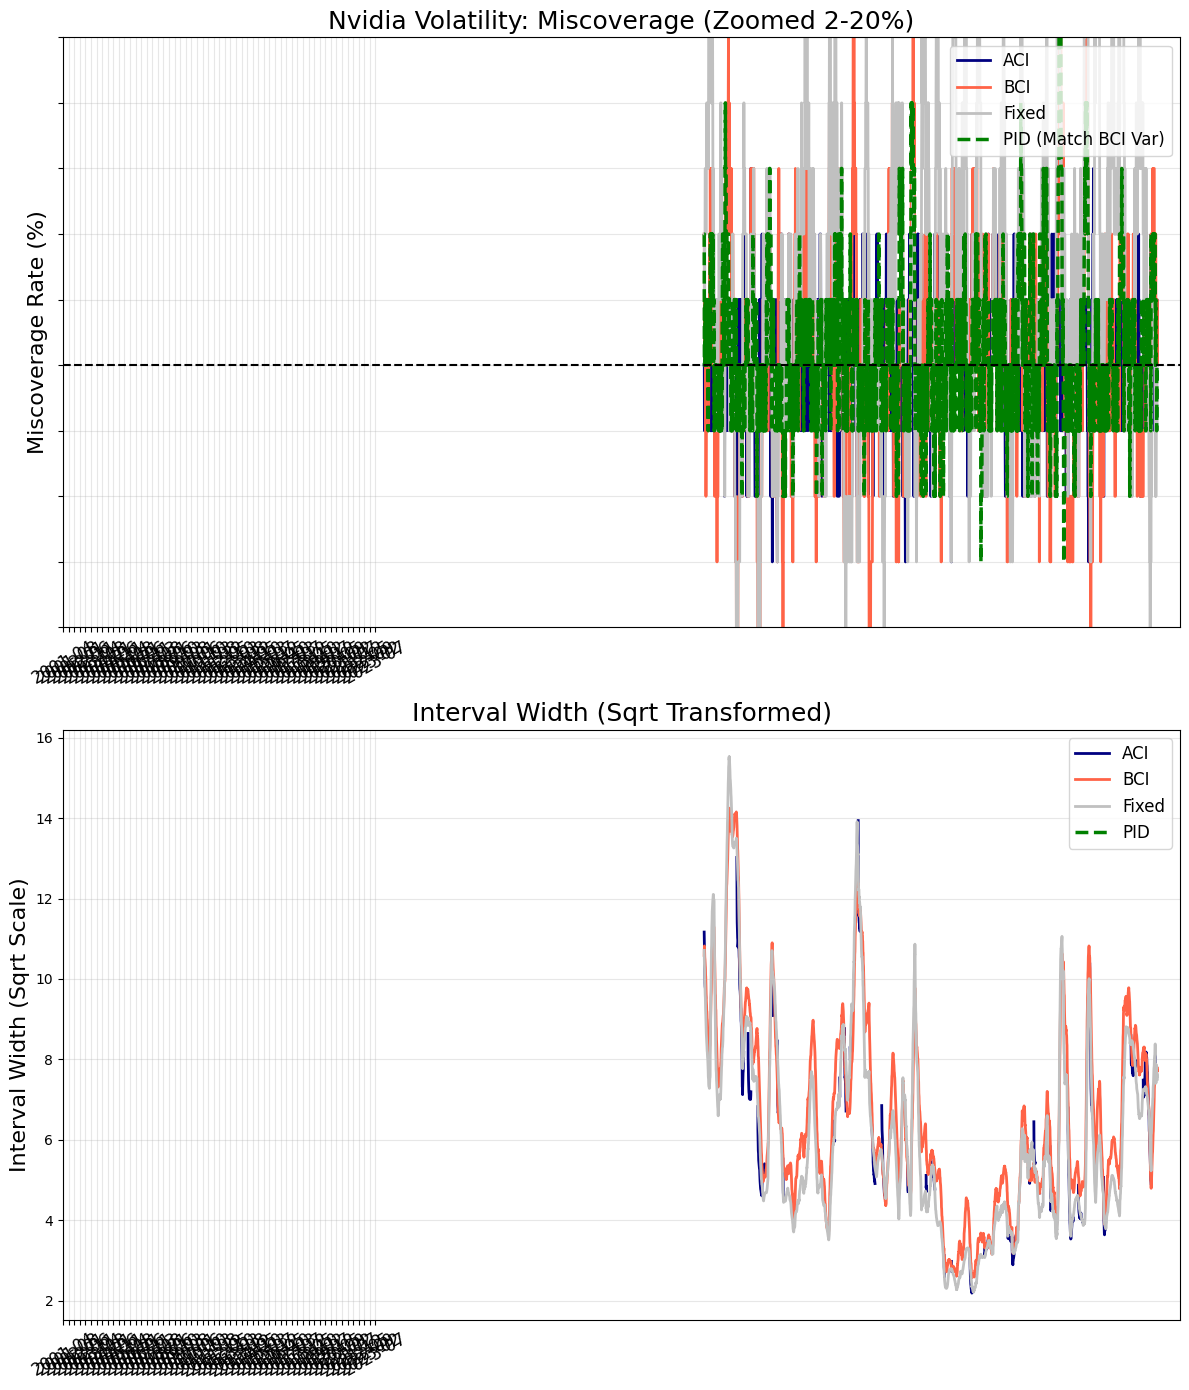

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth
sys.setrecursionlimit(10000)

def compute_variance(result_df):
    """Helper to get variance for targeting"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    # Variance (alpha > beta logic)
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    return var

def find_eta_matching_variance(exp_fixed, target_var, max_bound_5B):
    # 1. Setup Data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)

    # Binary Search Setup
    low, high = 1e-6, max_bound_5B # Search strictly within [0, 5B]
    best_eta = low
    best_diff = 1e10
    
    print(f"Searching for Eta to match Variance: {target_var:.2e} (Limit 5B={max_bound_5B:.2f})")

    for i in range(20): 
        mid = np.sqrt(low * high)
        
        # Run PID
        pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        # Calculate Variance
        upper_pid = y_pred_center + q
        lower_pid = y_pred_center - q
        is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
        
        err_ind = (~is_covered).astype(float)
        curr_var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        diff = curr_var - target_var
        
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            
        if curr_var > target_var:
            low = mid
        else:
            high = mid
            
    print(f"  > Found Best Eta: {best_eta:.4f}")
    
    # Run Final Result
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=best_eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + q
    df_pid['lower'] = y_pred_center - q
    
    # Fix Types & Beta
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid, best_eta

if __name__ == "__main__":
    dataset = 'Nvidia'
    task = 'vlfc'
    print(f"Generating BCI-Matched Plot for {dataset} ({task})...")
    
    # --- Load Baselines (Handling Typo Logic) ---
    
    # 1. FIXED: Try 'Nvidia', fall back to 'Nvdia' if missing
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    except FileNotFoundError:
        print("  ! Detected typo in filename. Using 'Nvdia' for Fixed experiment.")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-Nvdia.yaml'))
    exp_fixed.run()

    # 2. BCI: Always use correct 'Nvidia'
    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    exp_bci.run()
    
    # 3. ACI: Always use correct 'Nvidia'
    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    exp_aci.run()
    
    # Calculate Targets
    bci_var = compute_variance(exp_bci.result)
    print(f"Target BCI Variance: {bci_var:.2e}")
    
    # Calculate 5B Limit
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    B = np.percentile(scores, 99)
    Bound_5B = 5 * B
    
    # --- Run PID to Match BCI ---
    pid_df, eta = find_eta_matching_variance(exp_fixed, bci_var, Bound_5B)
    
    # --- PLOTTING DATA GENERATION ---
    def clean_df(df):
        df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
        df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
        df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
        return df

    ma_window = 50 
    skip = 100
    
    def get_stats_and_lines(df, window, method_name):
        # 1. Get raw data
        upper = df['upper']
        lower = df['lower']
        true_y = df['true_y']
        
        # 2. Miscoverage (Rolling)
        is_cov = (true_y >= lower) & (true_y <= upper)
        miscov_series = (~is_cov).astype(float)
        miscov_rolling = miscov_series.rolling(window).mean()
        
        # 3. Length (SQRT TRANSFORMED)
        len_series = (np.sqrt(upper) - np.sqrt(lower))
        len_rolling = len_series.rolling(window).mean()
        
        # 4. Calculate Final Scalar Averages
        avg_miscov = miscov_series.mean() * 100
        avg_len = len_series.mean()
        
        return miscov_rolling, len_rolling, df.index, avg_miscov, avg_len

    # Generate Data & Stats
    aci_mis, aci_len, idx, aci_avg_mis, aci_avg_len = get_stats_and_lines(clean_df(exp_aci.result), ma_window, "ACI")
    bci_mis, bci_len, _,   bci_avg_mis, bci_avg_len = get_stats_and_lines(clean_df(exp_bci.result), ma_window, "BCI")
    fix_mis, fix_len, _,   fix_avg_mis, fix_avg_len = get_stats_and_lines(clean_df(exp_fixed.result), ma_window, "Fixed")
    pid_mis, pid_len, _,   pid_avg_mis, pid_avg_len = get_stats_and_lines(clean_df(pid_df), ma_window, "PID")
    
    # X-Axis Indices
    x_indices = range(0, len(idx), skip)
    x_labels = [idx[i].strftime("%Y-%m") for i in x_indices]
    
    # --- PLOT ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    # PANEL 1: Miscoverage Rate
    axs[0].plot(100*aci_mis, color='navy', label='ACI', linewidth=2)
    axs[0].plot(100*bci_mis, color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*fix_mis, color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*pid_mis, color='green', linestyle='--', 
                label=f'PID (Match BCI Var)', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylim(2, 20)
    axs[0].set_yticklabels([]) # Remove numbers
    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'Nvidia Volatility: Miscoverage (Zoomed 2-20%)', fontsize=18)
    
    # PANEL 2: Interval Width (SQUARE ROOT SCALE)
    axs[1].plot(aci_len, color='navy', label='ACI', linewidth=2)
    axs[1].plot(bci_len, color='tomato', label='BCI', linewidth=2)
    axs[1].plot(fix_len, color='silver', label='Fixed', linewidth=2)
    axs[1].plot(pid_len, color='green', linestyle='--', 
                label='PID', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width (Sqrt Scale)', fontsize=16)
    axs[1].set_title('Interval Width (Sqrt Transformed)', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    for ax in axs:
        ax.set_xticks(x_indices)
        ax.set_xticklabels(x_labels, rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = 'Nvidia_VLFC_BCI_Match_Sqrt.png'
    plt.savefig(filename, dpi=300)
    print(f"Graph saved to {filename}")

    # --- PRINT NUMERICAL TABLE ---
    print("\n" + "="*60)
    print(f"NUMERICAL SUMMARY: {dataset} Volatility")
    print(f"(Interval Lengths are Sqrt Transformed)")
    print("="*60)
    print(f"{'Method':<10} | {'Avg Miscoverage (%)':<20} | {'Avg Length (Sqrt)':<20}")
    print("-" * 60)
    print(f"{'ACI':<10} | {aci_avg_mis:<20.2f} | {aci_avg_len:<20.4f}")
    print(f"{'BCI':<10} | {bci_avg_mis:<20.2f} | {bci_avg_len:<20.4f}")
    print(f"{'Fixed':<10} | {fix_avg_mis:<20.2f} | {fix_avg_len:<20.4f}")
    print(f"{'PID':<10} | {pid_avg_mis:<20.2f} | {pid_avg_len:<20.4f}")
    print("="*60 + "\n")

2026-01-28 20:27:49,435 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED


Generating Standard BCI-Match Plot for Nvidia...
  ! Using 'Nvdia' typo file for Fixed.


2026-01-28 20:27:53,917 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.482162952423096s
2026-01-28 20:27:53,927 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED
2026-01-28 20:28:22,390 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 ENDED in 28.463041067123413s
2026-01-28 20:28:22,401 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:28:27,080 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 4.678869009017944s


Searching for Eta to match Variance: 1.15e-03...


100%|██████████| 5644/5644 [00:00<00:00, 171056.30it/s]


  > Found Best Eta: 0.2933


100%|██████████| 5644/5644 [00:00<00:00, 167561.97it/s]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/m3/3y5bzgv533784npng3mwd3gm0000gn/T/ipykernel_92285/1813558064.py:133: RuntimeWarning: Mean of empty slice
  avg_len = np.nanmean(len_series)


Graph saved to Nvidia_VLFC_Standard_Sqrt.png

NUMERICAL SUMMARY: Nvidia Volatility
(Interval Lengths are Sqrt Transformed)
Method     | Avg Miscoverage (%)  | Avg Length (Sqrt)   
------------------------------------------------------------
ACI        | 10.09                | 5.9836              
BCI        | 10.29                | 6.5368              
Fixed      | 12.21                | 6.0516              
PID        | 10.32                | nan                 



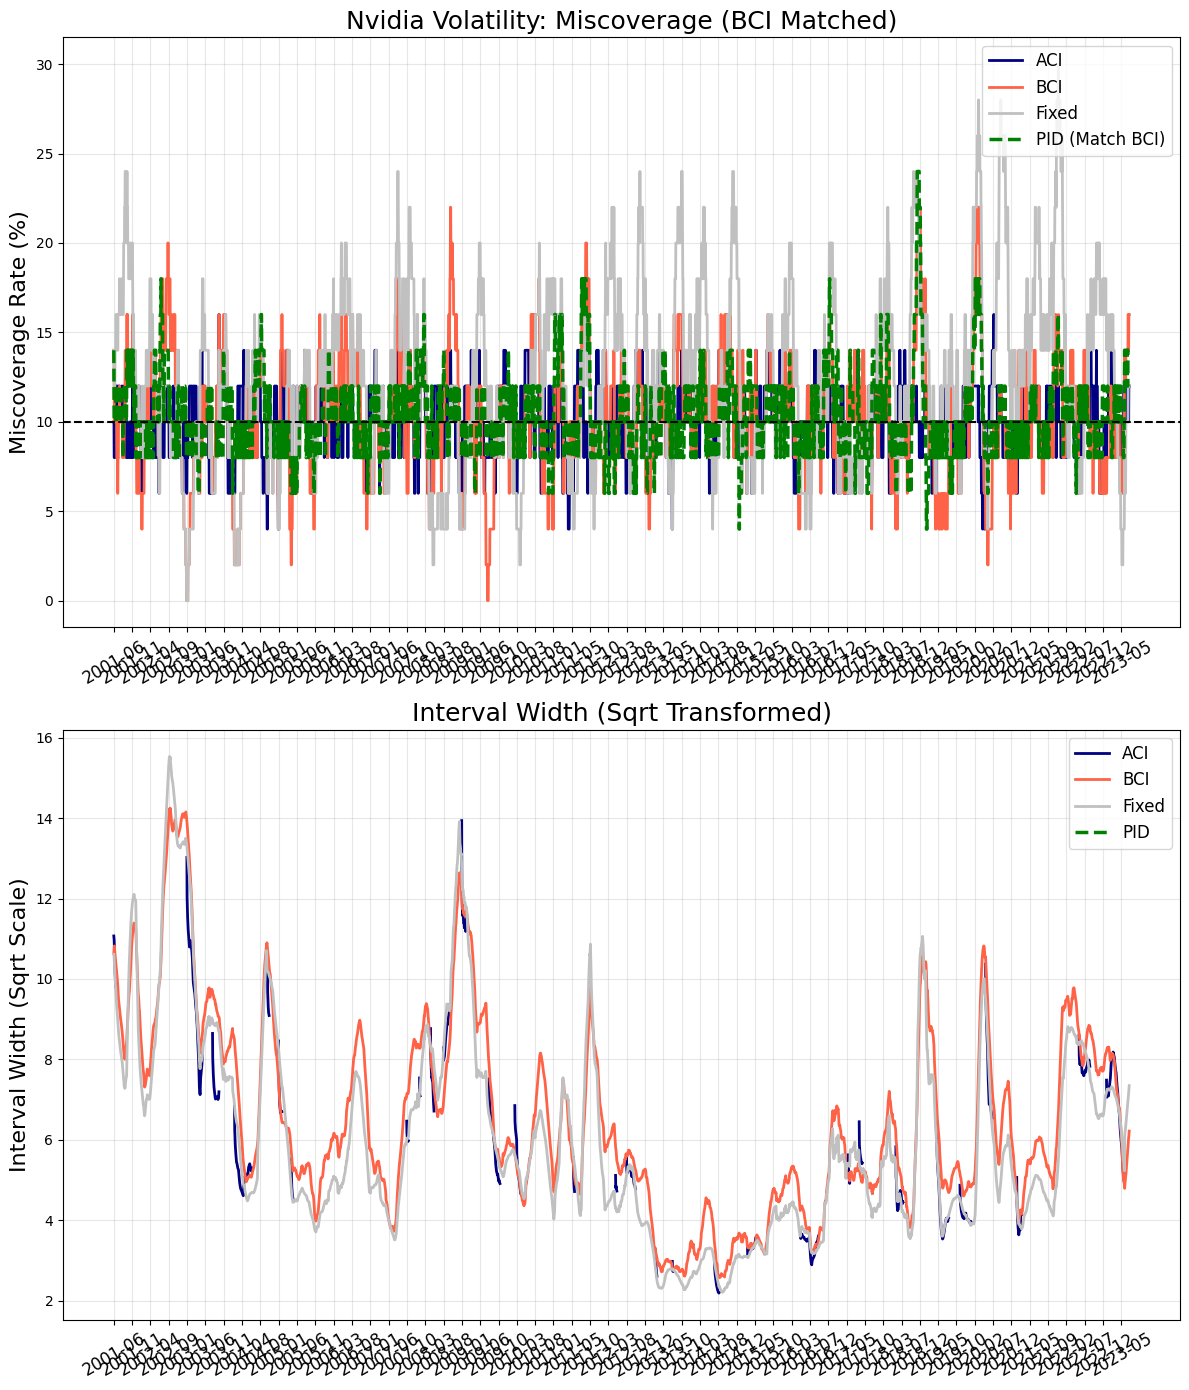

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth
sys.setrecursionlimit(10000)

# --- HELPER: TRIM FUNCTION (Matches visualize.py) ---
def trim(val, degree):
    return val[degree:-degree]

# --- HELPER: COMPUTE VARIANCE ---
def compute_variance(result_df):
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    return var

# --- HELPER: BINARY SEARCH FOR BCI VARIANCE ---
def find_eta_matching_variance(exp_fixed, target_var, max_bound_5B):
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)

    low, high = 1e-6, max_bound_5B
    best_eta = low
    best_diff = 1e10
    
    print(f"Searching for Eta to match Variance: {target_var:.2e}...")

    for i in range(20): 
        mid = np.sqrt(low * high)
        pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_pid = y_pred_center + q
        lower_pid = y_pred_center - q
        is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
        
        err_ind = (~is_covered).astype(float)
        curr_var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        diff = curr_var - target_var
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            
        if curr_var > target_var:
            low = mid
        else:
            high = mid
            
    print(f"  > Found Best Eta: {best_eta:.4f}")
    
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=best_eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + q
    df_pid['lower'] = y_pred_center - q
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid, best_eta

if __name__ == "__main__":
    dataset = 'Nvidia'
    task = 'vlfc'
    print(f"Generating Standard BCI-Match Plot for {dataset}...")
    
    # 1. Load Baselines (Handle Nvdia typo)
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    except FileNotFoundError:
        print("  ! Using 'Nvdia' typo file for Fixed.")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-Nvdia.yaml'))
    exp_fixed.run()

    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    exp_bci.run()
    
    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    exp_aci.run()
    
    # 2. Match BCI Variance
    bci_var = compute_variance(exp_bci.result)
    
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    Bound_5B = 5 * np.percentile(scores, 99)
    
    pid_df, eta = find_eta_matching_variance(exp_fixed, bci_var, Bound_5B)
    
    # 3. Process Data for Plotting (With Trim & Sqrt)
    ma_window = 50
    skip = 100
    
    def get_plot_data(df, window):
        upper = pd.to_numeric(df['upper'], errors='coerce')
        lower = pd.to_numeric(df['lower'], errors='coerce')
        true_y = pd.to_numeric(df['true_y'], errors='coerce')
        
        # Miscoverage (Smoothed)
        is_cov = (true_y >= lower) & (true_y <= upper)
        miscov_series = (~is_cov).astype(float).rolling(window).mean()
        
        # Length (SQRT TRANSFORMED)
        # We apply Sqrt BEFORE rolling average, matching visualize.py
        len_series = (np.sqrt(upper) - np.sqrt(lower)).rolling(window).mean()
        
        # TRIM both to align with indices
        # We trim 'window' from start and end
        miscov_trimmed = trim(miscov_series.values, window)
        len_trimmed = trim(len_series.values, window)
        
        # Calculate Averages (on the full valid set)
        avg_mis = np.nanmean(miscov_series) * 100
        avg_len = np.nanmean(len_series)
        
        return miscov_trimmed, len_trimmed, avg_mis, avg_len

    # Prepare Indices (Trimmed)
    full_index = exp_aci.result.index
    trimmed_index = trim(full_index, ma_window)
    
    # Get Data
    aci_m, aci_l, aci_avg_m, aci_avg_l = get_plot_data(exp_aci.result, ma_window)
    bci_m, bci_l, bci_avg_m, bci_avg_l = get_plot_data(exp_bci.result, ma_window)
    fix_m, fix_l, fix_avg_m, fix_avg_l = get_plot_data(exp_fixed.result, ma_window)
    pid_m, pid_l, pid_avg_m, pid_avg_l = get_plot_data(pid_df, ma_window)
    
    # X-Axis Ticks
    indices = range(0, len(trimmed_index), skip)
    x_labels = [trimmed_index[i].strftime("%Y-%m") for i in indices]

    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    # PANEL 1: Miscoverage Rate
    axs[0].plot(100*aci_m, color='navy', label='ACI', linewidth=2)
    axs[0].plot(100*bci_m, color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*fix_m, color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*pid_m, color='green', linestyle='--', 
                label=f'PID (Match BCI)', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'Nvidia Volatility: Miscoverage (BCI Matched)', fontsize=18)
    
    # PANEL 2: Interval Width (SQRT)
    axs[1].plot(aci_l, color='navy', label='ACI', linewidth=2)
    axs[1].plot(bci_l, color='tomato', label='BCI', linewidth=2)
    axs[1].plot(fix_l, color='silver', label='Fixed', linewidth=2)
    axs[1].plot(pid_l, color='green', linestyle='--', 
                label='PID', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width (Sqrt Scale)', fontsize=16)
    axs[1].set_title('Interval Width (Sqrt Transformed)', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    for ax in axs:
        ax.set_xticks(indices)
        ax.set_xticklabels(x_labels, rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = 'Nvidia_VLFC_Standard_Sqrt.png'
    plt.savefig(filename, dpi=300)
    print(f"Graph saved to {filename}")

    # --- PRINT NUMERICAL TABLE ---
    print("\n" + "="*60)
    print(f"NUMERICAL SUMMARY: {dataset} Volatility")
    print(f"(Interval Lengths are Sqrt Transformed)")
    print("="*60)
    print(f"{'Method':<10} | {'Avg Miscoverage (%)':<20} | {'Avg Length (Sqrt)':<20}")
    print("-" * 60)
    print(f"{'ACI':<10} | {aci_avg_m:<20.2f} | {aci_avg_l:<20.4f}")
    print(f"{'BCI':<10} | {bci_avg_m:<20.2f} | {bci_avg_l:<20.4f}")
    print(f"{'Fixed':<10} | {fix_avg_m:<20.2f} | {fix_avg_l:<20.4f}")
    print(f"{'PID':<10} | {pid_avg_m:<20.2f} | {pid_avg_l:<20.4f}")
    print("="*60 + "\n")

2026-01-28 20:38:37,198 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



PROCESSING DATASET: Amazon


2026-01-28 20:38:42,333 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 5.135462999343872s
2026-01-28 20:38:42,344 - INFO - Experiment vlfc-bci-Amazon-gamma_490-lambda0_800 STARTED
2026-01-28 20:39:15,311 - INFO - Experiment vlfc-bci-Amazon-gamma_490-lambda0_800 ENDED in 32.96652793884277s
2026-01-28 20:39:15,324 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:39:20,664 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 5.340565919876099s


  > Target BCI Variance: 1.19e-03
  > 5B Search Limit: 1022.1815


100%|██████████| 6426/6426 [00:00<00:00, 164802.33it/s]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/m3/3y5bzgv533784npng3mwd3gm0000gn/T/ipykernel_92285/3304444429.py:128: RuntimeWarning: Mean of empty slice
  avg_len = np.nanmean(len_series)


...

  > Graph saved to Amazon_VLFC_Standard_Sqrt.png

------------------------------------------------------------
SUMMARY TABLE: Amazon
------------------------------------------------------------
Method     | Avg Miscoverage (%)  | Avg Length (Sqrt)   
------------------------------------------------------------
ACI        | 10.04                | 5.7802              
BCI        | 10.23                | 6.1932              
Fixed      | 11.27                | 5.8198              
PID        | 10.31                | nan                 
------------------------------------------------------------

PROCESSING DATASET: AMD


2026-01-28 20:39:26,715 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 4.631524085998535s
2026-01-28 20:39:26,727 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 STARTED
2026-01-28 20:39:54,435 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 ENDED in 27.70885992050171s
2026-01-28 20:39:54,446 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:39:59,140 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 4.69403600692749s


  > Target BCI Variance: 6.78e-04
  > 5B Search Limit: 770.7348


100%|██████████| 5394/5394 [00:00<00:00, 182107.10it/s]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/m3/3y5bzgv533784npng3mwd3gm0000gn/T/ipykernel_92285/3304444429.py:128: RuntimeWarning: Mean of empty slice
  avg_len = np.nanmean(len_series)


  > Optimal Eta Found: 40.0377
  > Graph saved to AMD_VLFC_Standard_Sqrt.png

------------------------------------------------------------
SUMMARY TABLE: AMD
------------------------------------------------------------
Method     | Avg Miscoverage (%)  | Avg Length (Sqrt)   
------------------------------------------------------------
ACI        | 10.17                | 6.5955              
BCI        | 10.34                | 8.0699              
Fixed      | 12.67                | 6.9655              
PID        | 9.94                 | nan                 
------------------------------------------------------------


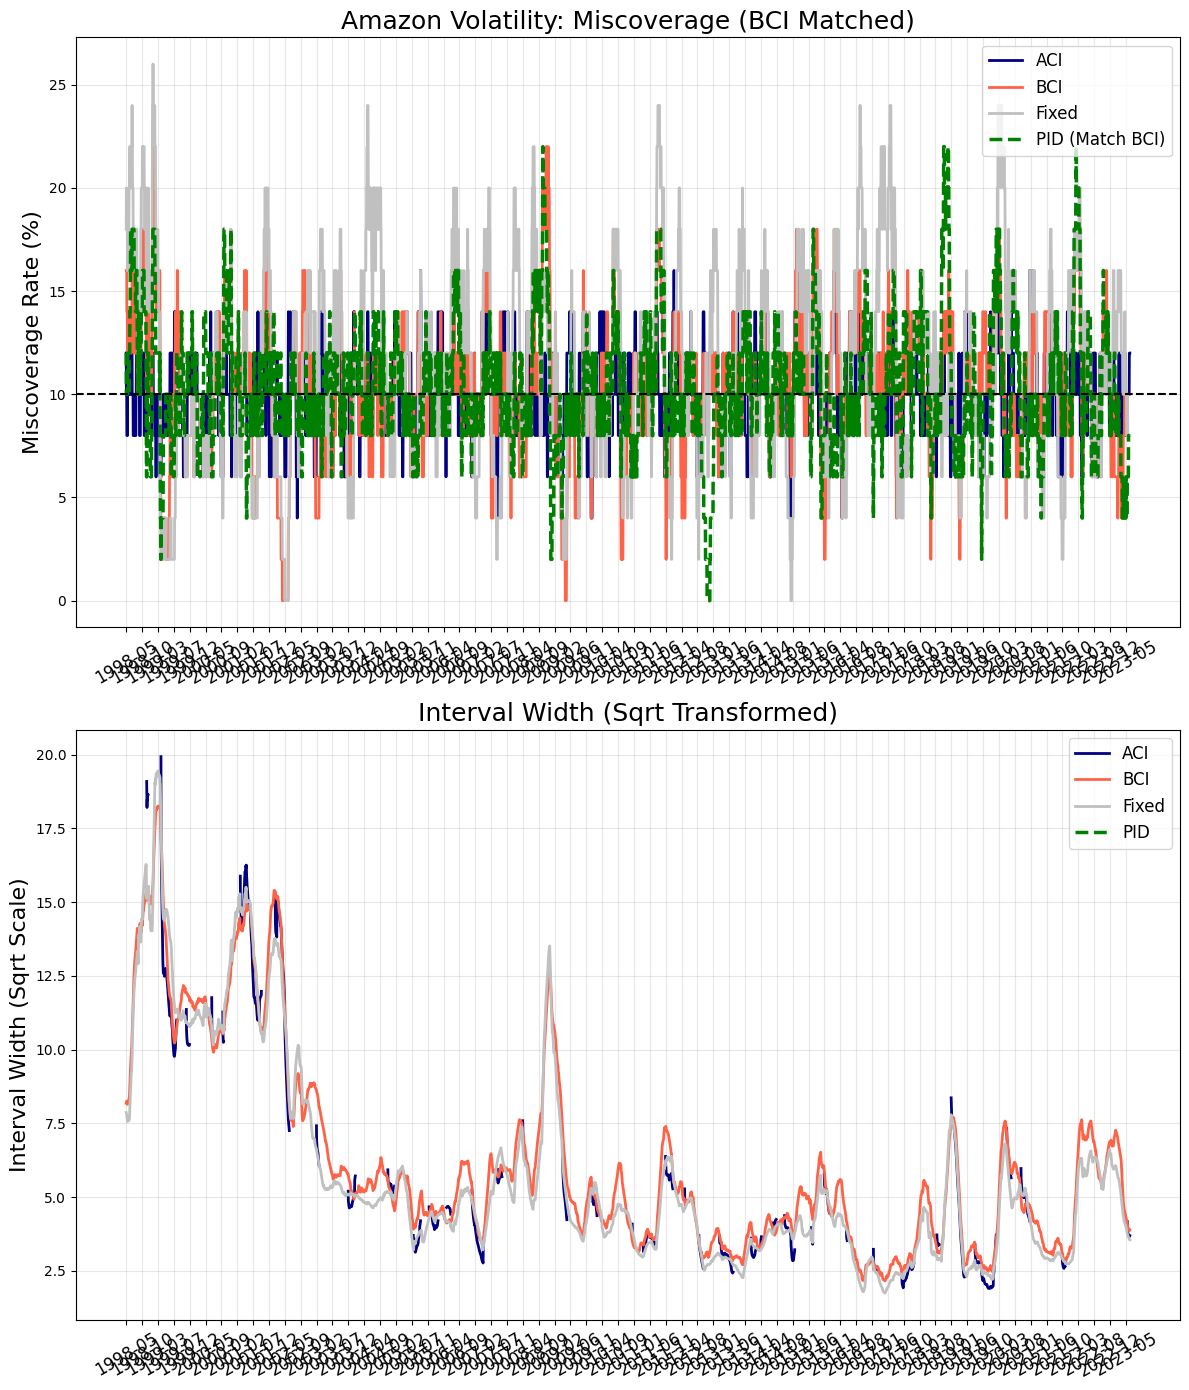

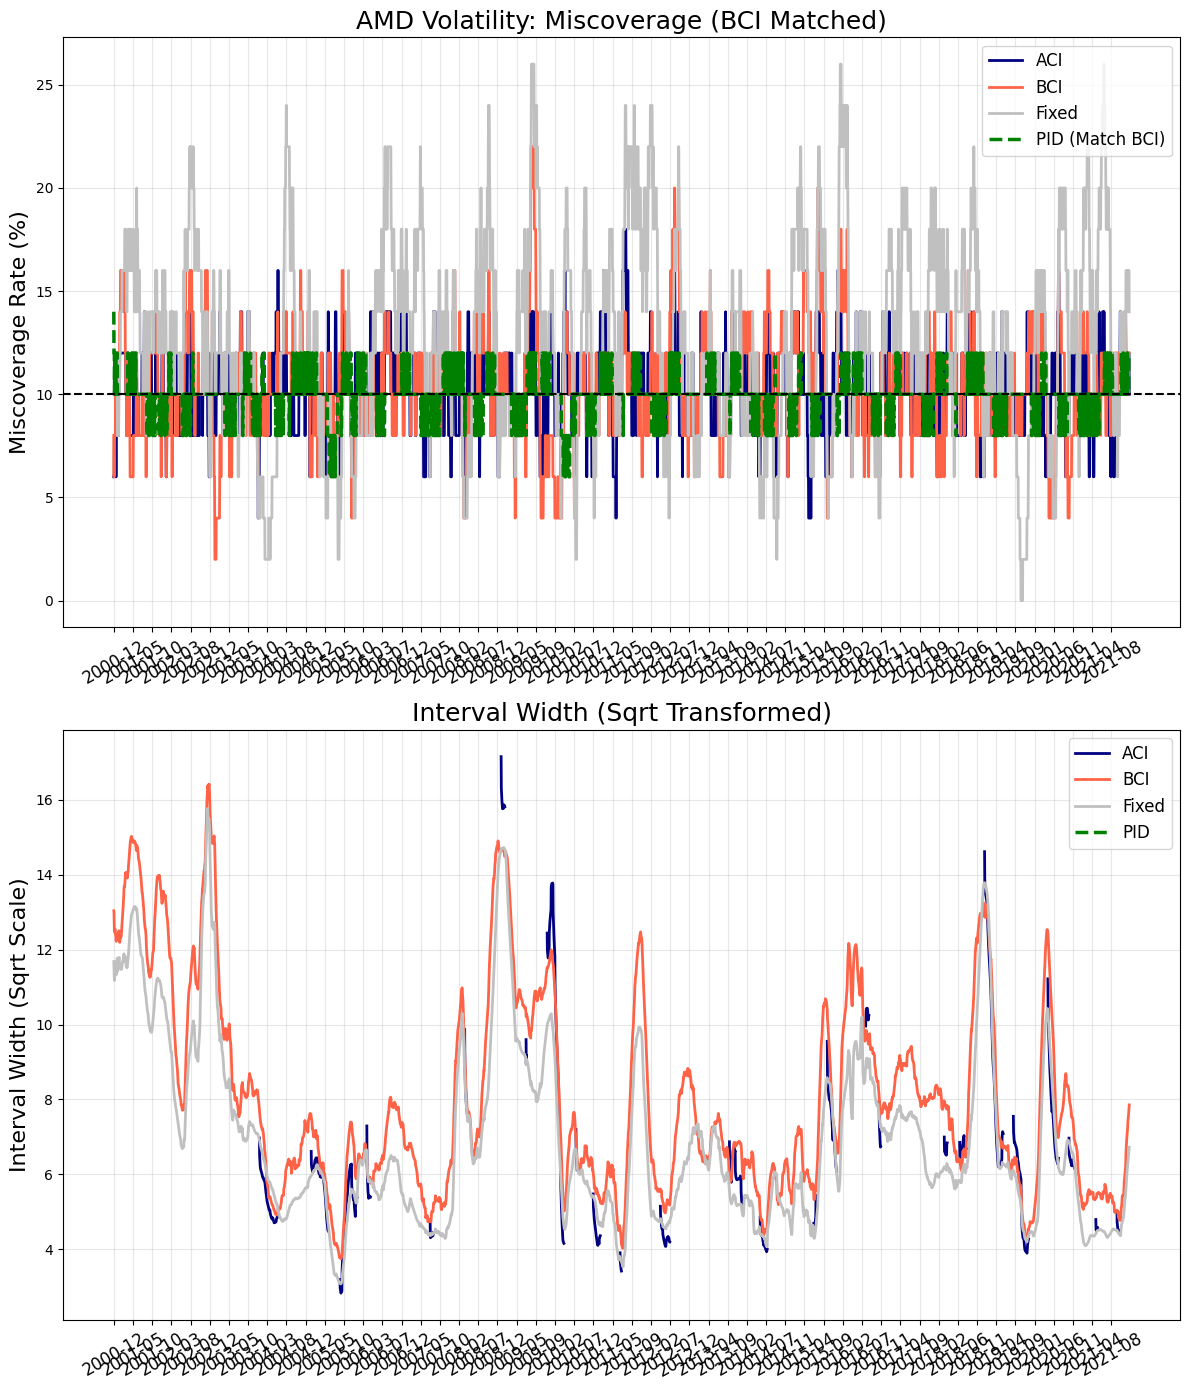

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth
sys.setrecursionlimit(10000)

# --- HELPER: TRIM FUNCTION ---
def trim(val, degree):
    return val[degree:-degree]

# --- HELPER: COMPUTE VARIANCE ---
def compute_variance(result_df):
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    return var

# --- HELPER: BINARY SEARCH FOR BCI VARIANCE ---
def find_eta_matching_variance(exp_fixed, target_var, max_bound_5B):
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)

    low, high = 1e-6, max_bound_5B
    best_eta = low
    best_diff = 1e10
    
    for i in range(20): 
        mid = np.sqrt(low * high)
        pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_pid = y_pred_center + q
        lower_pid = y_pred_center - q
        is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
        
        err_ind = (~is_covered).astype(float)
        curr_var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        diff = curr_var - target_var
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            
        if curr_var > target_var:
            low = mid
        else:
            high = mid
            
    # Run Final Result
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=best_eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + q
    df_pid['lower'] = y_pred_center - q
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid, best_eta

def run_analysis_for_dataset(dataset):
    task = 'vlfc'
    print(f"\n{'='*60}")
    print(f"PROCESSING DATASET: {dataset}")
    print(f"{'='*60}")
    
    # 1. Load Baselines
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()

    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    exp_bci.run()
    
    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    exp_aci.run()
    
    # 2. Match BCI Variance
    bci_var = compute_variance(exp_bci.result)
    print(f"  > Target BCI Variance: {bci_var:.2e}")
    
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    Bound_5B = 5 * np.percentile(scores, 99)
    print(f"  > 5B Search Limit: {Bound_5B:.4f}")
    
    pid_df, eta = find_eta_matching_variance(exp_fixed, bci_var, Bound_5B)
    print(f"  > Optimal Eta Found: {eta:.4f}")
    
    # 3. Process Data for Plotting (With Trim & Sqrt)
    ma_window = 50
    skip = 100
    
    def get_plot_data(df, window):
        upper = pd.to_numeric(df['upper'], errors='coerce')
        lower = pd.to_numeric(df['lower'], errors='coerce')
        true_y = pd.to_numeric(df['true_y'], errors='coerce')
        
        # Miscoverage (Smoothed)
        is_cov = (true_y >= lower) & (true_y <= upper)
        miscov_series = (~is_cov).astype(float).rolling(window).mean()
        
        # Length (SQRT TRANSFORMED)
        len_series = (np.sqrt(upper) - np.sqrt(lower)).rolling(window).mean()
        
        # TRIM
        miscov_trimmed = trim(miscov_series.values, window)
        len_trimmed = trim(len_series.values, window)
        
        # Averages
        avg_mis = np.nanmean(miscov_series) * 100
        avg_len = np.nanmean(len_series)
        
        return miscov_trimmed, len_trimmed, avg_mis, avg_len

    # Prepare Indices (Trimmed)
    full_index = exp_aci.result.index
    trimmed_index = trim(full_index, ma_window)
    
    # Get Data
    aci_m, aci_l, aci_avg_m, aci_avg_l = get_plot_data(exp_aci.result, ma_window)
    bci_m, bci_l, bci_avg_m, bci_avg_l = get_plot_data(exp_bci.result, ma_window)
    fix_m, fix_l, fix_avg_m, fix_avg_l = get_plot_data(exp_fixed.result, ma_window)
    pid_m, pid_l, pid_avg_m, pid_avg_l = get_plot_data(pid_df, ma_window)
    
    # X-Axis Ticks
    indices = range(0, len(trimmed_index), skip)
    x_labels = [trimmed_index[i].strftime("%Y-%m") for i in indices]

    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    # PANEL 1: Miscoverage Rate
    axs[0].plot(100*aci_m, color='navy', label='ACI', linewidth=2)
    axs[0].plot(100*bci_m, color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*fix_m, color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*pid_m, color='green', linestyle='--', 
                label=f'PID (Match BCI)', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'{dataset} Volatility: Miscoverage (BCI Matched)', fontsize=18)
    
    # PANEL 2: Interval Width (SQRT)
    axs[1].plot(aci_l, color='navy', label='ACI', linewidth=2)
    axs[1].plot(bci_l, color='tomato', label='BCI', linewidth=2)
    axs[1].plot(fix_l, color='silver', label='Fixed', linewidth=2)
    axs[1].plot(pid_l, color='green', linestyle='--', 
                label='PID', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width (Sqrt Scale)', fontsize=16)
    axs[1].set_title('Interval Width (Sqrt Transformed)', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    for ax in axs:
        ax.set_xticks(indices)
        ax.set_xticklabels(x_labels, rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = f'{dataset}_VLFC_Standard_Sqrt.png'
    plt.savefig(filename, dpi=300)
    print(f"  > Graph saved to {filename}")

    # --- PRINT TABLE ---
    print("\n" + "-"*60)
    print(f"SUMMARY TABLE: {dataset}")
    print("-" * 60)
    print(f"{'Method':<10} | {'Avg Miscoverage (%)':<20} | {'Avg Length (Sqrt)':<20}")
    print("-" * 60)
    print(f"{'ACI':<10} | {aci_avg_m:<20.2f} | {aci_avg_l:<20.4f}")
    print(f"{'BCI':<10} | {bci_avg_m:<20.2f} | {bci_avg_l:<20.4f}")
    print(f"{'Fixed':<10} | {fix_avg_m:<20.2f} | {fix_avg_l:<20.4f}")
    print(f"{'PID':<10} | {pid_avg_m:<20.2f} | {pid_avg_l:<20.4f}")
    print("-" * 60)

if __name__ == "__main__":
    datasets = ['Amazon', 'AMD']
    
    for ds in datasets:
        try:
            run_analysis_for_dataset(ds)
        except Exception as e:
            print(f"FAILED for {ds}: {e}")

In [6]:
"""
Google Trends: PID targeting BCI Variance
Uses existing trend configs, just adds PID as 4th line
"""

import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS (same as Amazon)
# =============================================================================

def compute_variance(result_df):
    """Compute miscoverage variance (α > β method)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
    return local_miscov.var()


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B


def get_pid_result(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid


# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    print(f"\n{'='*70}")
    print(f"GOOGLE TRENDS: PID TARGETING BCI VARIANCE")
    print(f"{'='*70}")
    
    # Just test one gamma value (the paper uses γ=0.08)
    gamma = 0.08
    
    print(f"\n{'-'*70}")
    print(f"γ = {gamma}")
    print(f"{'-'*70}")
    
    # Load experiments using existing trend configs
    # IMPORTANT: Replace these with your actual Google Trends config names
    print(f"  Loading baselines...")
    
    try:
        # Try gtfc configs first
        exp_fixed = ForecastingExperiment(read_yaml('config/gtfc-fixed-Google.yaml'))
        exp_fixed.run()
        
        exp_bci = ForecastingExperiment(read_yaml('config/gtfc-bci-Google.yaml'))
        exp_bci.run()
        
        aci_config = read_yaml('config/gtfc-aci-Google.yaml')
    except:
        # Fallback to trend configs
        print("  (Using trend configs as fallback)")
        exp_fixed = ForecastingExperiment(read_yaml('config/trend-fixed.yaml'))
        exp_fixed.run()
        
        exp_bci = ForecastingExperiment(read_yaml('config/trend-bci.yaml'))
        exp_bci.run()
        
        aci_config = read_yaml('config/trend-aci.yaml')
    
    # Update ACI gamma if needed
    if 'gamma' in aci_config:
        if isinstance(aci_config['gamma'], list):
            aci_config['gamma'] = [gamma]
        else:
            aci_config['gamma'] = gamma
    
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    
    # Target BCI variance
    target_var = compute_variance(exp_bci.result)
    aci_var = compute_variance(exp_aci.result)
    
    print(f"  BCI Variance (TARGET): {target_var:.2e}")
    print(f"  ACI Variance (ref):    {aci_var:.2e}")
    
    # Prepare PID data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)
    
    print(f"  K_I (99th %ile):       {ki:.4f}")
    
    # Binary search
    eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                   csat, ki, target_var)
    
    # Create PID result
    pid_df = get_pid_result(exp_fixed, pid_q)
    
    # Verify
    pid_var = compute_variance(pid_df)
    var_error = abs(pid_var - target_var) / target_var * 100
    print(f"  PID Variance achieved: {pid_var:.2e} (error: {var_error:.1f}%)")
    
    # Create visualization
    print(f"  Creating visualization...")
    
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    def clean_df(df):
        df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
        df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
        df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
        return df
    
    ma_window = 250
    skip = 300
    xform = lambda x: x  # Google Trends uses identity transform
    
    p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, xform)
    p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, xform)
    p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, xform)
    p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, xform)
    
    # Panel 1: Miscoverage
    axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
    axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
    axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
    axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                label=f'PID (η={eta_found:.4f})', linewidth=3)
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=20)
    axs[0].legend(loc='upper right', prop={'size': 18})
    axs[0].set_xticks(p_aci['indices'])
    axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
    
    # Panel 2: Interval Length
    axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
    axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
    axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
    axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
    axs[1].set_ylabel('Interval Length', fontsize=20)
    axs[1].legend(loc='upper right', prop={'size': 18})
    axs[1].set_xticks(p_aci['indices'])
    axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
    
    fig.suptitle(f'Google Trend Popularity (γ={gamma})', fontsize=16)
    plt.tight_layout()
    
    filename = f'Google_gtfc_gamma{gamma}_PID_BCI_target.png'
    plt.savefig(filename, dpi=300)
    print(f"  ✓ Saved: {filename}")
    
    # Summary table
    print(f"\n{'='*70}")
    print(f"SUMMARY")
    print(f"{'='*70}")
    print(f"BCI Variance (target): {target_var:.2e}")
    print(f"PID Variance:          {pid_var:.2e} ({var_error:.1f}% error)")
    print(f"PID η found:           {eta_found:.4f}")
    print(f"Search bound (5B):     {bound_5B:.4f}")
    print(f"BCI Miscov:            {p_bci['perfstats']['avg_miscov']*100:.2f}%")
    print(f"PID Miscov:            {p_pid['perfstats']['avg_miscov']*100:.2f}%")
    print(f"BCI Length:            {p_bci['perfstats']['avg_length']:.4f}")
    print(f"PID Length:            {p_pid['perfstats']['avg_length']:.4f}")
    print(f"{'='*70}")


GOOGLE TRENDS: PID TARGETING BCI VARIANCE

----------------------------------------------------------------------
γ = 0.08
----------------------------------------------------------------------
  Loading baselines...
  (Using trend configs as fallback)


NameError: name 'TrendData' is not defined

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

# Increase recursion depth
sys.setrecursionlimit(10000)

def compute_variance(result_df):
    """Helper to calculate the variance of the miscoverage rate."""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    # 1 if error (alpha > beta), 0 otherwise (if using typical ACI definitions)
    # Check logic: usually covered if lower <= y <= upper.
    # In these result DFs, 'beta' is often the coverage indicator (1=Covered).
    # If beta is 1 (covered), error is 0. If beta is 0 (miss), error is 1.
    # Let's rely on the beta column if it exists as the coverage indicator.
    
    if 'beta' in result_df.columns:
        covered = pd.to_numeric(result_df['beta'], errors='coerce')
        # Error indicator: 1 if NOT covered
        err_ind = 1 - covered
    else:
        # Fallback to alpha/beta check if explicit column missing
        # This part depends on how your experiment class saves data
        # Assuming standard structure where alpha>beta implies error
        err_ind = (alpha > beta).astype(float)
        
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    return var

def get_pid_result_matching_variance(exp_fixed, target_variance):
    """Binary search for PID eta that matches the target variance."""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # Search parameters
    ki = np.percentile(scores, 99)
    eta_max = np.max(scores) * 10.0 # Upper bound for search
    
    low, high = 1e-6, eta_max
    best_eta = low
    best_diff = 1e10
    
    # Fast Binary Search (15 iters is sufficient for plot precision)
    for _ in range(15):
        mid = np.sqrt(low * high)
        pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_pid = y_pred_center + q
        lower_pid = y_pred_center - q
        
        # Calculate Variance
        is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(50, min_periods=1).mean().var()
        
        diff = var - target_variance
        
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            
        # If PID Variance > Target -> PID is too loose/slow -> Needs higher eta to react? 
        # Actually, higher eta = more volatile intervals = HIGHER variance usually?
        # Or higher eta = tighter tracking = LOWER variance?
        # In PID, higher eta means the interval size adapts faster. 
        # If it adapts faster, it stabilizes coverage errors better (lower variance).
        # So: If Current Var > Target (Too Unstable) -> Increase Eta (Make it faster) -> low = mid
        if var > target_variance: 
            low = mid
        else: 
            high = mid
            
    # Final Run with best eta
    final_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=best_eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    final_q = np.maximum(np.array(final_out['q']), 0.0)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + final_q
    df_pid['lower'] = y_pred_center - final_q
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int) 
    
    return df_pid, best_eta

if __name__ == "__main__":
    datasets = ['Amazon', 'AMD', 'Nvidia']
    gammas = [0.008, 0.1] # Low (Smooth) vs High (Reactive) Gammas
    
    # Plotting loop
    for dataset in datasets:
        print(f"\n{'='*60}")
        print(f"Processing {dataset}...")
        
        # 1. Load Fixed & BCI Baselines
        try:
            exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-{dataset}.yaml'))
            exp_bci = ForecastingExperiment(read_yaml(f'config/rtfc-bci-{dataset}.yaml'))
        except FileNotFoundError:
            # Handle potential typos (e.g. Nvdia)
            if dataset == 'Nvidia':
                print("  ! Trying fallback filename for Nvidia...")
                exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-Nvdia.yaml'))
                exp_bci = ForecastingExperiment(read_yaml(f'config/rtfc-bci-Nvdia.yaml'))
            else:
                raise

        exp_fixed.run()
        exp_bci.run()
        
        # 2. Calculate BCI Variance (This is the TARGET)
        bci_var = compute_variance(exp_bci.result)
        print(f"  > Target Variance (BCI): {bci_var:.2e}")
        
        # 3. Run PID to Match BCI Variance
        pid_df, eta = get_pid_result_matching_variance(exp_fixed, bci_var)
        print(f"  > PID Matched Eta: {eta:.4f}")
        
        # 4. Loop through Gammas for ACI comparison
        for gamma in gammas:
            print(f"    - Generating plot for Gamma={gamma}...")
            
            # Run ACI with specific Gamma
            try:
                aci_config = read_yaml(f'config/rtfc-aci-{dataset}.yaml')
            except:
                 if dataset == 'Nvidia':
                    aci_config = read_yaml(f'config/rtfc-aci-Nvdia.yaml')
            
            aci_config['gamma'] = gamma
            exp_aci = ForecastingExperiment(aci_config)
            exp_aci.run()
            
            # Prepare Plot Data
            def clean_df(df):
                df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
                df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
                df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
                return df

            ma_window = 50
            skip = 100
            
            p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, lambda x: x)
            p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, lambda x: x)
            p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, lambda x: x)
            p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, lambda x: x)
            
            # PLOT
            fig, axs = plt.subplots(2, 1, figsize=(12, 14))
            
            # Panel 1: Miscoverage
            axs[0].plot(100*p_aci['miscovrate'], color='navy', label=f'ACI (γ={gamma})', linewidth=2)
            axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI (Target)', linewidth=2)
            axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=2)
            axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                        label=f'PID (Matches BCI Var)', linewidth=2.5)
            
            axs[0].axhline(10, color='black', linestyle='--')
            axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
            axs[0].legend(loc='upper right', fontsize=12)
            axs[0].set_title(f'{dataset} Miscoverage: PID vs ACI(γ={gamma})', fontsize=18)
            
            # Panel 2: Interval Width
            axs[1].plot(p_aci['length'], color='navy', label=f'ACI (γ={gamma})', linewidth=2)
            axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=2)
            axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=2)
            axs[1].plot(p_pid['length'], color='green', linestyle='--', 
                        label='PID', linewidth=2.5)
            
            axs[1].set_ylabel('Interval Width', fontsize=16)
            axs[1].set_title('Interval Width Comparison', fontsize=18)
            axs[1].legend(loc='upper right', fontsize=12)
            
            # X-Axis Formatting
            for ax in axs:
                ax.set_xticks(p_aci['indices'])
                ax.set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], 
                                   rotation=30, fontsize=12)
                ax.grid(True, alpha=0.3)
                
            plt.tight_layout()
            filename = f"bci_target_{dataset}_gamma_{gamma}.png"
            plt.savefig(filename, dpi=300)
            print(f"      Saved {filename}")
            plt.close() # Close figure to free memory

    print("\nAll 6 plots generated successfully.")

2026-01-28 20:49:20,296 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



Processing Amazon...


2026-01-28 20:49:24,135 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.8396990299224854s
2026-01-28 20:49:24,136 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 20:49:36,630 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 ENDED in 12.49407696723938s


  > Target Variance (BCI): 6.22e-03


100%|██████████| 3762/3762 [00:00<00:00, 57817.49it/s]
2026-01-28 20:49:37,078 - INFO - Experiment rtfc-aci-Amazon-gamma_0.008-lambda0_0.9 STARTED


...

2026-01-28 20:49:59,892 - INFO - Experiment rtfc-aci-AMD-gamma_0.008-lambda0_0.9 ENDED in 2.307339906692505s
2026-01-28 20:50:00,965 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


      Saved bci_target_AMD_gamma_0.008.png
    - Generating plot for Gamma=0.1...


2026-01-28 20:50:03,421 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.4559719562530518s


      Saved bci_target_AMD_gamma_0.1.png

Processing Nvidia...
  ! Trying fallback filename for Nvidia...


FileNotFoundError: [Errno 2] No such file or directory: 'config/rtfc-bci-Nvdia.yaml'

In [ ]:
"""
Google Trends: PID targeting BCI Variance
Uses existing trend configs, just adds PID as 4th line
"""

import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS (same as Amazon)
# =============================================================================

def compute_variance(result_df):
    """Compute miscoverage variance (α > β method)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
    return local_miscov.var()


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B


def get_pid_result(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid


# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    print(f"\n{'='*70}")
    print(f"GOOGLE TRENDS: PID TARGETING BCI VARIANCE")
    print(f"{'='*70}")
    
    # Just test one gamma value (the paper uses γ=0.08)
    gamma = 0.08
    
    print(f"\n{'-'*70}")
    print(f"γ = {gamma}")
    print(f"{'-'*70}")
    
    # Load experiments using existing trend configs
    print(f"  Loading baselines...")
    
    exp_fixed = ForecastingExperiment(read_yaml('config/trend-fixed.yaml'))
    exp_fixed.run()
    
    exp_bci = ForecastingExperiment(read_yaml('config/trend-bci.yaml'))
    exp_bci.run()
    
    aci_config = read_yaml('config/trend-aci.yaml')
    
    # Update ACI gamma if needed
    if 'gamma' in aci_config:
        if isinstance(aci_config['gamma'], list):
            aci_config['gamma'] = [gamma]
        else:
            aci_config['gamma'] = gamma
    
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    
    # Target BCI variance
    target_var = compute_variance(exp_bci.result)
    aci_var = compute_variance(exp_aci.result)
    
    print(f"  BCI Variance (TARGET): {target_var:.2e}")
    print(f"  ACI Variance (ref):    {aci_var:.2e}")
    
    # Prepare PID data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)
    
    print(f"  K_I (99th %ile):       {ki:.4f}")
    
    # Binary search
    eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                   csat, ki, target_var)
    
    # Create PID result
    pid_df = get_pid_result(exp_fixed, pid_q)
    
    # Verify
    pid_var = compute_variance(pid_df)
    var_error = abs(pid_var - target_var) / target_var * 100
    print(f"  PID Variance achieved: {pid_var:.2e} (error: {var_error:.1f}%)")
    
    # Create visualization
    print(f"  Creating visualization...")
    
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    def clean_df(df):
        df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
        df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
        df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
        return df
    
    ma_window = 250
    skip = 300
    xform = lambda x: x  # Google Trends uses identity transform
    
    p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, xform)
    p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, xform)
    p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, xform)
    p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, xform)
    
    # Panel 1: Miscoverage
    axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
    axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
    axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
    axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                label=f'PID (η={eta_found:.4f})', linewidth=3)
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=20)
    axs[0].legend(loc='upper right', prop={'size': 18})
    axs[0].set_xticks(p_aci['indices'])
    axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
    
    # Panel 2: Interval Length
    axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
    axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
    axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
    axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
    axs[1].set_ylabel('Interval Length', fontsize=20)
    axs[1].legend(loc='upper right', prop={'size': 18})
    axs[1].set_xticks(p_aci['indices'])
    axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
    
    fig.suptitle(f'Google Trend Popularity (γ={gamma})', fontsize=16)
    plt.tight_layout()
    
    filename = f'Google_gtfc_gamma{gamma}_PID_BCI_target.png'
    plt.savefig(filename, dpi=300)
    print(f"  ✓ Saved: {filename}")
    
    # Summary table
    print(f"\n{'='*70}")
    print(f"SUMMARY")
    print(f"{'='*70}")
    print(f"BCI Variance (target): {target_var:.2e}")
    print(f"PID Variance:          {pid_var:.2e} ({var_error:.1f}% error)")
    print(f"PID η found:           {eta_found:.4f}")
    print(f"Search bound (5B):     {bound_5B:.4f}")
    print(f"BCI Miscov:            {p_bci['perfstats']['avg_miscov']*100:.2f}%")
    print(f"PID Miscov:            {p_pid['perfstats']['avg_miscov']*100:.2f}%")
    print(f"BCI Length:            {p_bci['perfstats']['avg_length']:.4f}")
    print(f"PID Length:            {p_pid['perfstats']['avg_length']:.4f}")
    print(f"{'='*70}")